# Process and reformat tecan data, then background normalize the NGAC assay for upload to HiTS

In [1]:
import pandas as pd
import string
import sys
sys.path.append("/Users/apaulson/repos/data-proc")
import plate_maps as pm
import seaborn as sns
import numpy as np

In [3]:
dat = pd.read_csv("/Volumes/Shared/SMDC/Screens/2025_users_temp/Deepthi/all_data/AMP glo assay rawdata.csv")

# find starting/ending index
label_col = dat.columns[0]

start_row = dat.loc[dat[label_col].eq("Cycle Nr.")].index[0]
end_row = dat.loc[dat[label_col].eq("End Time")].index[0]
dat=dat[start_row:end_row]

dat=dat.dropna(how='all', axis=0)
dat.columns=dat.iloc[0]
dat=dat[1:]
dat=dat.T
dat.columns=dat.iloc[1]
dat=dat[3:]
dat=dat.reset_index(names='well')
dat['row'] = dat['well'].str.extract('([A-Z]+)')
dat['col'] = dat['well'].str.extract('(\d+)')
dat['col'] = dat['col'].astype(int)
dat=dat.melt(id_vars=['well', 'row', 'col'], var_name='time', value_name='intensity')
dat['well'] = dat['row'] + dat['col'].astype(str).str.zfill(2)
dat.intensity=dat.intensity.astype(float)
dat.time=dat.time.astype(float)
dat

,well,row,col,time,intensity
0,A01,A,1,0.000,1007.0
1,A02,A,2,0.000,963.0
2,A03,A,3,0.000,1155.0
3,A04,A,4,0.000,937.0
4,A05,A,5,0.000,1027.0
...,...,...,...,...,...
4603,P20,P,20,6600.145,10.0
4604,P21,P,21,6600.145,6.0
4605,P22,P,22,6600.145,21.0
4606,P23,P,23,6600.145,8.0


In [4]:
platemap=pd.read_excel("/Volumes/Shared/SMDC/Screens/2025_users_temp/Deepthi/all_data/NCAG_DR_TC.xlsx", sheet_name=None)
platemap.keys()

dict_keys(['Info', 'TARG_AMPglo_P1', 'TARG_AMPglo_ctrl_P1'])

In [5]:
platemap['Info']

,Grid_num,Lots,Source_plate,Assay_name,Raw_assay_ID,Date_of_screen,Raw_data_file,Comments,Control,Control_lot
0,TARG_AMPglo_P1,use map,NaN,TARG_AMPglo,2807,2026-02-06,/Volumes/Shared/SMDC/Screens/2025_users_temp/D...,TECAN TIMECOURSE,NaN,NaN
1,TARG_AMPglo_ctrl_P1,use map,NaN,TARG_AMPglo_counter,2809,2026-02-06,/Volumes/Shared/SMDC/Screens/2025_users_temp/D...,TECAN TIMECOURSE,NaN,NaN


In [6]:
nudt5=pm.read_platemap_block(platemap['TARG_AMPglo_ctrl_P1'], block=0, value_name='SMDC_ID')
nudt5['well']=nudt5.row+nudt5.col.astype(str).str.zfill(2)
nudt5=nudt5[(nudt5.SMDC_ID.notna())&(nudt5.SMDC_ID!='positive control')&(nudt5.SMDC_ID!='Negative control')]
nudt5_wells=nudt5.well.unique()
nconc=pm.read_platemap_block(platemap['TARG_AMPglo_ctrl_P1'], block=1, value_name='conc')
nconc['well']=nconc.row+nconc.col.astype(str).str.zfill(2)
nconc=nconc[nconc.well.isin(nudt5_wells)]
nudt5_conc=pd.merge(nudt5, nconc, how='left')
nudt5_conc['nudt5_only']=True
print(nudt5_conc.shape)
nudt5_conc.head()

(48, 6)


,row,col,SMDC_ID,well,conc,nudt5_only
0,G,01,1128295,G01,50,True
1,H,01,1128295,H01,25,True
2,I,01,1128295,I01,12.5,True
3,J,01,1128295,J01,6.25,True
4,G,02,1128295,G02,50,True


In [7]:
ids=pm.read_platemap_block(platemap['TARG_AMPglo_P1'], block=0, value_name='SMDC_ID')
ids=ids.dropna(subset=['SMDC_ID'])
ids['well']=ids.row+ids.col.astype(str).str.zfill(2)
print(len(ids))

concs=pm.read_platemap_block(platemap['TARG_AMPglo_P1'], block=1, value_name='conc')
concs=concs.dropna(subset=['conc'])
concs['well']=concs.row+concs.col.astype(str).str.zfill(2)
concs=concs[['well', 'conc']]
ids_conc=ids.merge(concs, on='well', how='left')
ids_conc['nudt5_only']=False
ids_conc.shape

72


(72, 6)

In [8]:
all_ids=pd.concat([ids_conc, nudt5_conc], axis=0, ignore_index=True)
print(all_ids.shape)
all_ids.head()

(120, 6)


,row,col,SMDC_ID,well,conc,nudt5_only
0,B,01,1128295,B01,50,False
1,C,01,1128295,C01,25,False
2,D,01,1128295,D01,12.5,False
3,E,01,1128295,E01,6.25,False
4,K,01,positive control,K01,NaN,False


In [9]:
dat['col']=dat.col.astype(int)
all_ids['col']=all_ids.col.astype(int)

In [10]:
dat_id_conc=all_ids.merge(dat, how='outer')
dat_id_conc.shape

(4608, 8)

In [11]:
dat_id_conc.SMDC_ID.unique()

array([nan, 1128295, 1128944, 1128230, 1128834, 'positive control',
       'Negative control'], dtype=object)

In [12]:
dat_id_conc.head()

,row,col,SMDC_ID,well,conc,nudt5_only,time,intensity
0,A,1,NaN,A01,NaN,NaN,0.000,1007.0
1,A,1,NaN,A01,NaN,NaN,600.010,3119.0
2,A,1,NaN,A01,NaN,NaN,1200.023,4670.0
3,A,1,NaN,A01,NaN,NaN,1800.038,5859.0
4,A,1,NaN,A01,NaN,NaN,2400.053,7028.0


In [13]:
dat_id_conc.conc=dat_id_conc.conc.fillna(0)
print(dat_id_conc.shape)
dat_id_conc=dat_id_conc.dropna(subset=['SMDC_ID'])
dat_id_conc.SMDC_ID=dat_id_conc.SMDC_ID.astype(str)
print(dat_id_conc.shape)

(4608, 8)
(1440, 8)


In [14]:
dat_id_conc[['nudt5_only', 'SMDC_ID']].value_counts()

nudt5_only  SMDC_ID         
False       1128230             144
            1128295             144
            1128834             144
            1128944             144
            Negative control    144
            positive control    144
True        1128230             144
            1128295             144
            1128834             144
            1128944             144
Name: count, dtype: int64

In [15]:
dat_id_conc['intensity_bgsub']=None
dat_id_conc['intensity_activity']=None
dat_id_conc['intensity_inhibition']=None
for time in dat_id_conc.time.unique():
    dat_time=dat_id_conc[dat_id_conc.time==time].copy()

    dat_time_ctrl_mean=dat_time[(dat_time.nudt5_only==True)&(dat_time.conc!=100)].intensity.mean()
    dat_time['intensity_bgsub']=dat_time.intensity-dat_time_ctrl_mean
    dat_id_conc.loc[dat_id_conc.time==time, 'intensity_bgsub']=dat_time.intensity_bgsub

    dat_time_pos_mean=dat_time[dat_time.SMDC_ID=='positive control'].intensity_bgsub.mean() # don't flip the control
    dat_time_neg_mean=dat_time[dat_time.SMDC_ID=='Negative control'].intensity_bgsub.mean() # don't flip the control

    dat_id_conc.loc[dat_id_conc.time==time, 'intensity_activity']=(dat_id_conc.intensity_bgsub-dat_time_neg_mean)/(dat_time_pos_mean-dat_time_neg_mean)*100
    dat_id_conc.loc[dat_id_conc.time==time, 'intensity_inhibition']=100-dat_id_conc.intensity_activity
dat_id_conc

,row,col,SMDC_ID,well,conc,nudt5_only,time,intensity,intensity_bgsub,intensity_activity,intensity_inhibition
288,B,1,1128295,B01,50,False,0.000,1455.0,662.291667,65.455386,34.544614
289,B,1,1128295,B01,50,False,600.010,3632.0,1931.166667,91.998713,8.001287
290,B,1,1128295,B01,50,False,1200.023,5155.0,2682.0625,92.097512,7.902488
291,B,1,1128295,B01,50,False,1800.038,6258.0,3120.208333,86.933701,13.066299
292,B,1,1128295,B01,50,False,2400.053,7846.0,4088.354167,95.415703,4.584297
...,...,...,...,...,...,...,...,...,...,...,...
3307,L,12,Negative control,L12,0,False,4200.092,5221.0,5.854167,5.176813,94.823187
3308,L,12,Negative control,L12,0,False,4800.100,5470.0,-133.125,3.710975,96.289025
3309,L,12,Negative control,L12,0,False,5400.119,5675.0,-269.520833,1.723694,98.276306
3310,L,12,Negative control,L12,0,False,6000.129,6094.0,-130.895833,4.508088,95.491912


In [16]:
dat_id_conc

,row,col,SMDC_ID,well,conc,nudt5_only,time,intensity,intensity_bgsub,intensity_activity,intensity_inhibition
288,B,1,1128295,B01,50,False,0.000,1455.0,662.291667,65.455386,34.544614
289,B,1,1128295,B01,50,False,600.010,3632.0,1931.166667,91.998713,8.001287
290,B,1,1128295,B01,50,False,1200.023,5155.0,2682.0625,92.097512,7.902488
291,B,1,1128295,B01,50,False,1800.038,6258.0,3120.208333,86.933701,13.066299
292,B,1,1128295,B01,50,False,2400.053,7846.0,4088.354167,95.415703,4.584297
...,...,...,...,...,...,...,...,...,...,...,...
3307,L,12,Negative control,L12,0,False,4200.092,5221.0,5.854167,5.176813,94.823187
3308,L,12,Negative control,L12,0,False,4800.100,5470.0,-133.125,3.710975,96.289025
3309,L,12,Negative control,L12,0,False,5400.119,5675.0,-269.520833,1.723694,98.276306
3310,L,12,Negative control,L12,0,False,6000.129,6094.0,-130.895833,4.508088,95.491912


In [17]:
dat_id_conc=dat_id_conc.sort_values('SMDC_ID').reset_index(drop=True)

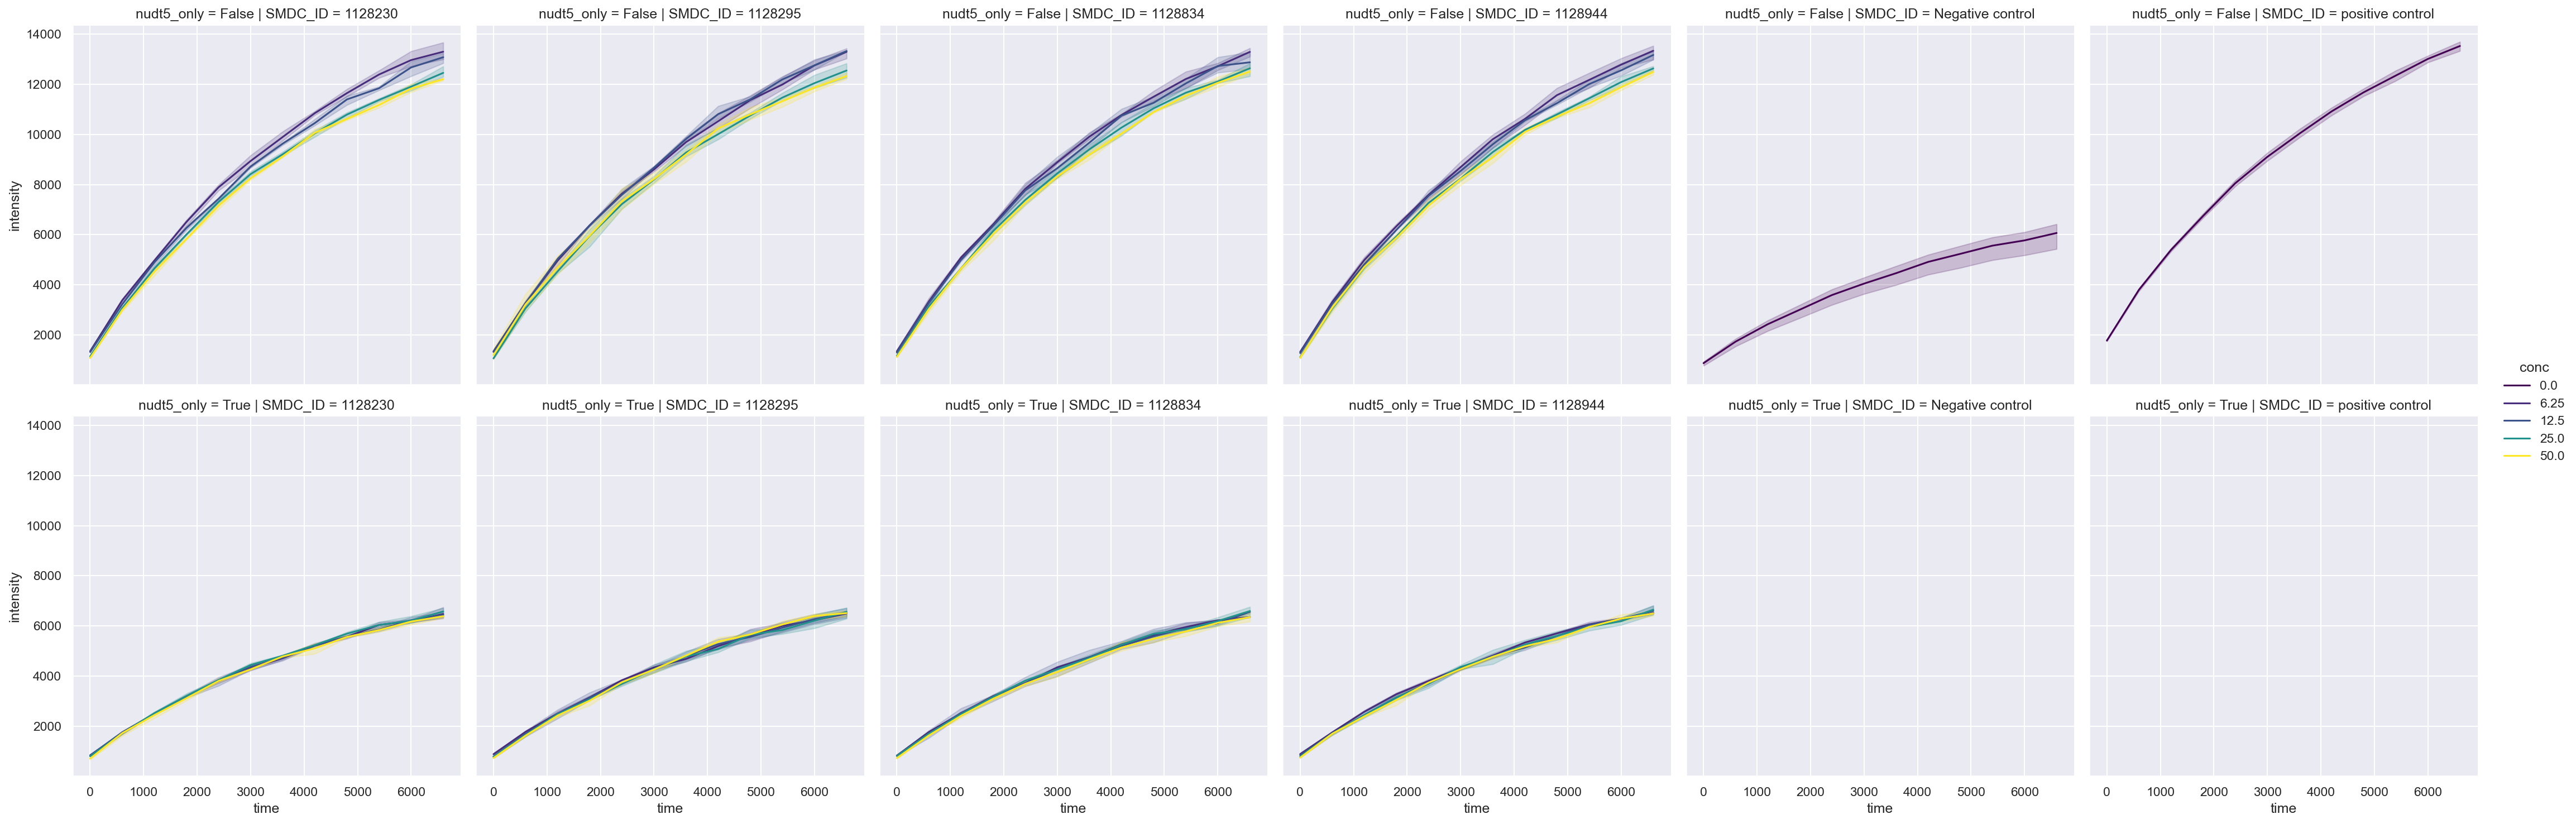

In [18]:
sns.relplot(data=dat_id_conc, x='time', y='intensity', hue='conc', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

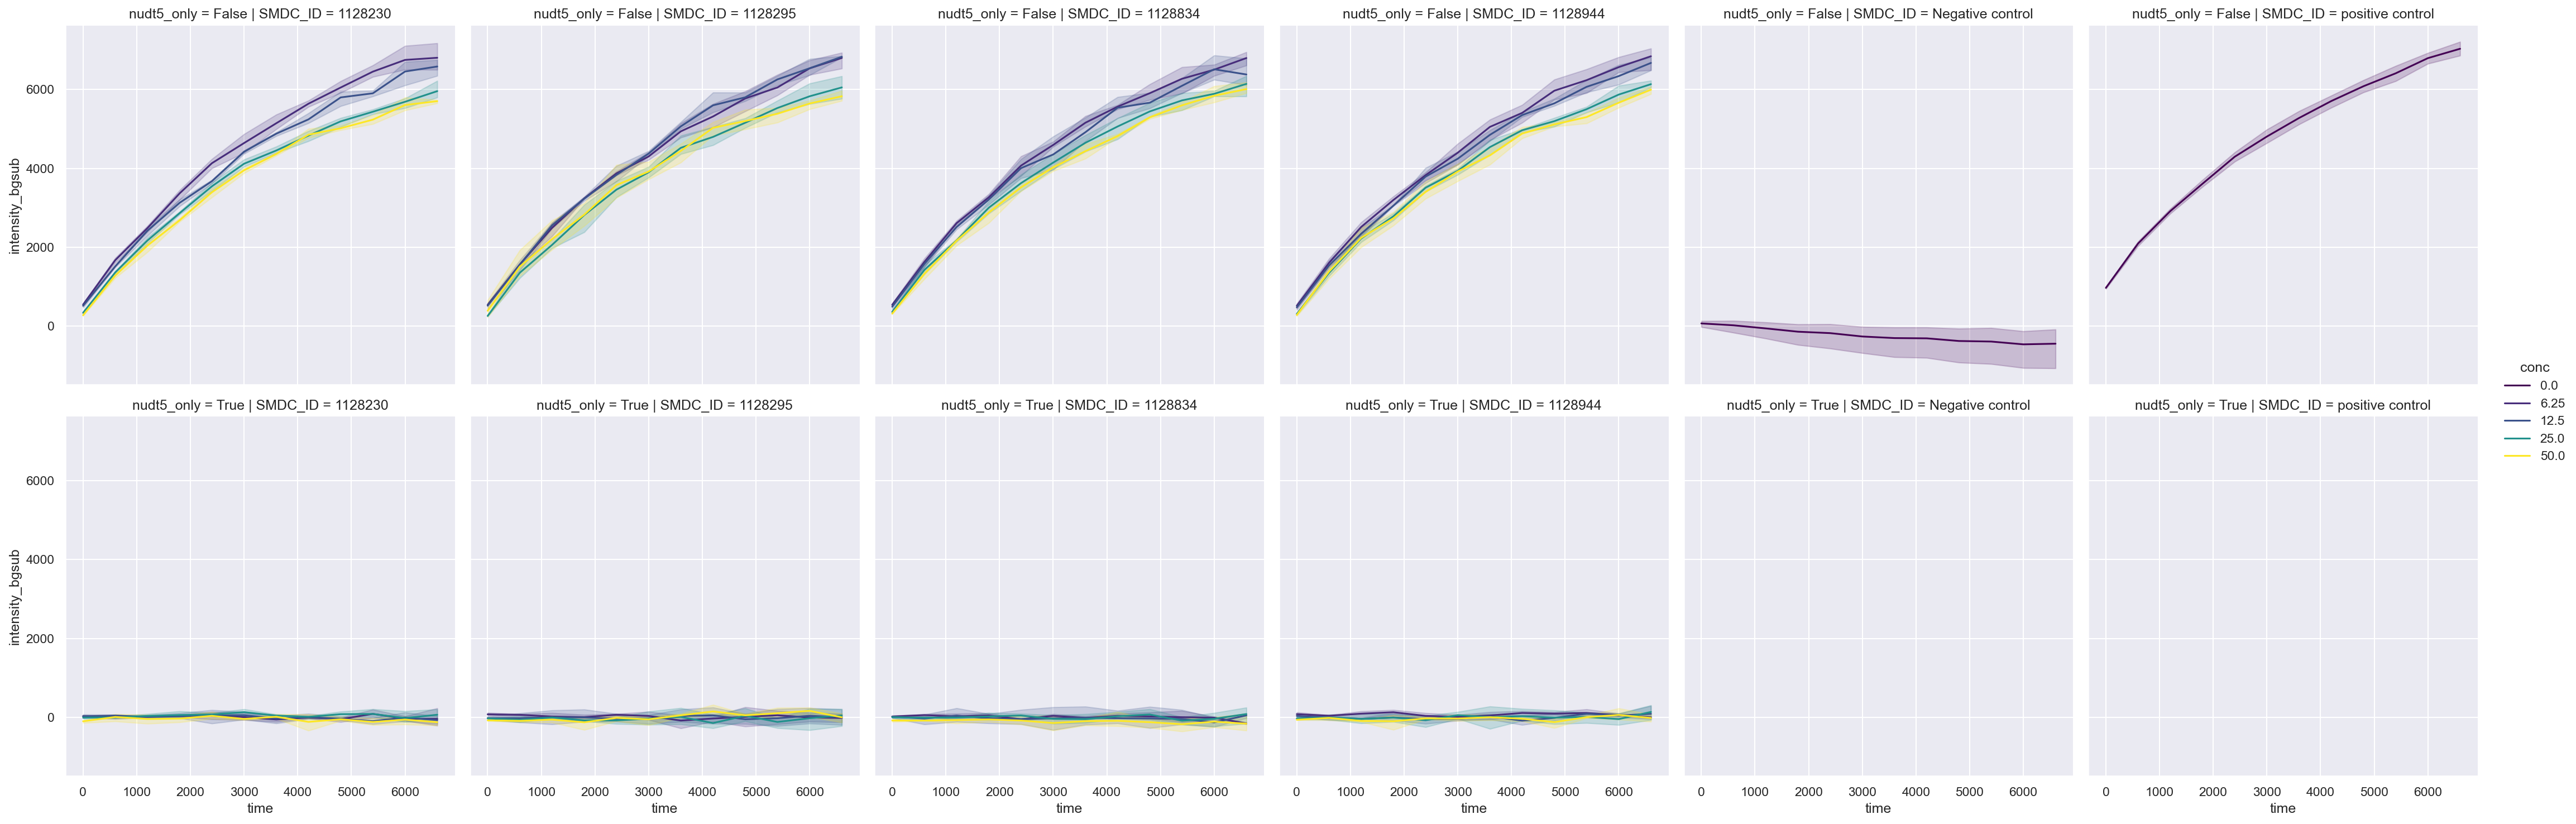

In [19]:
sns.relplot(data=dat_id_conc, x='time', y='intensity_bgsub', hue='conc', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

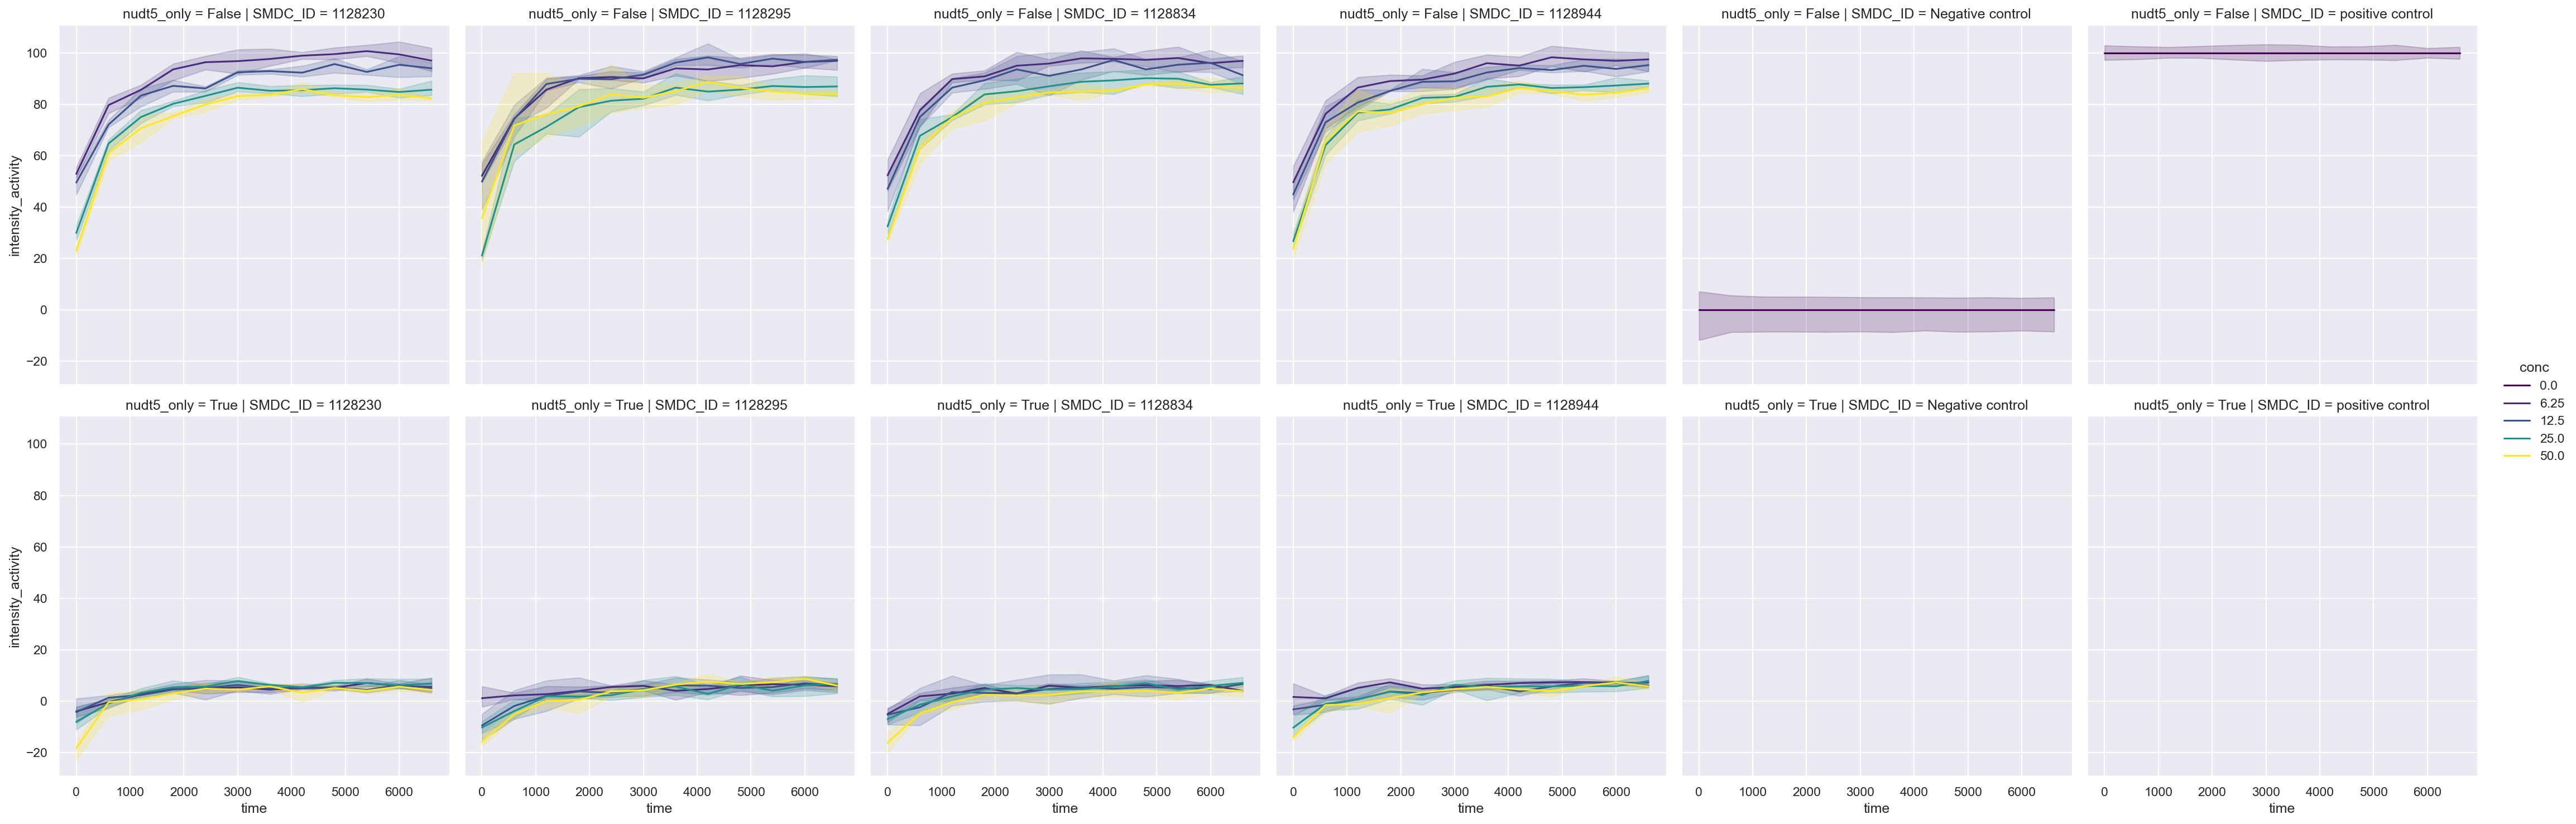

In [20]:
sns.relplot(data=dat_id_conc, x='time', y='intensity_activity', hue='conc', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

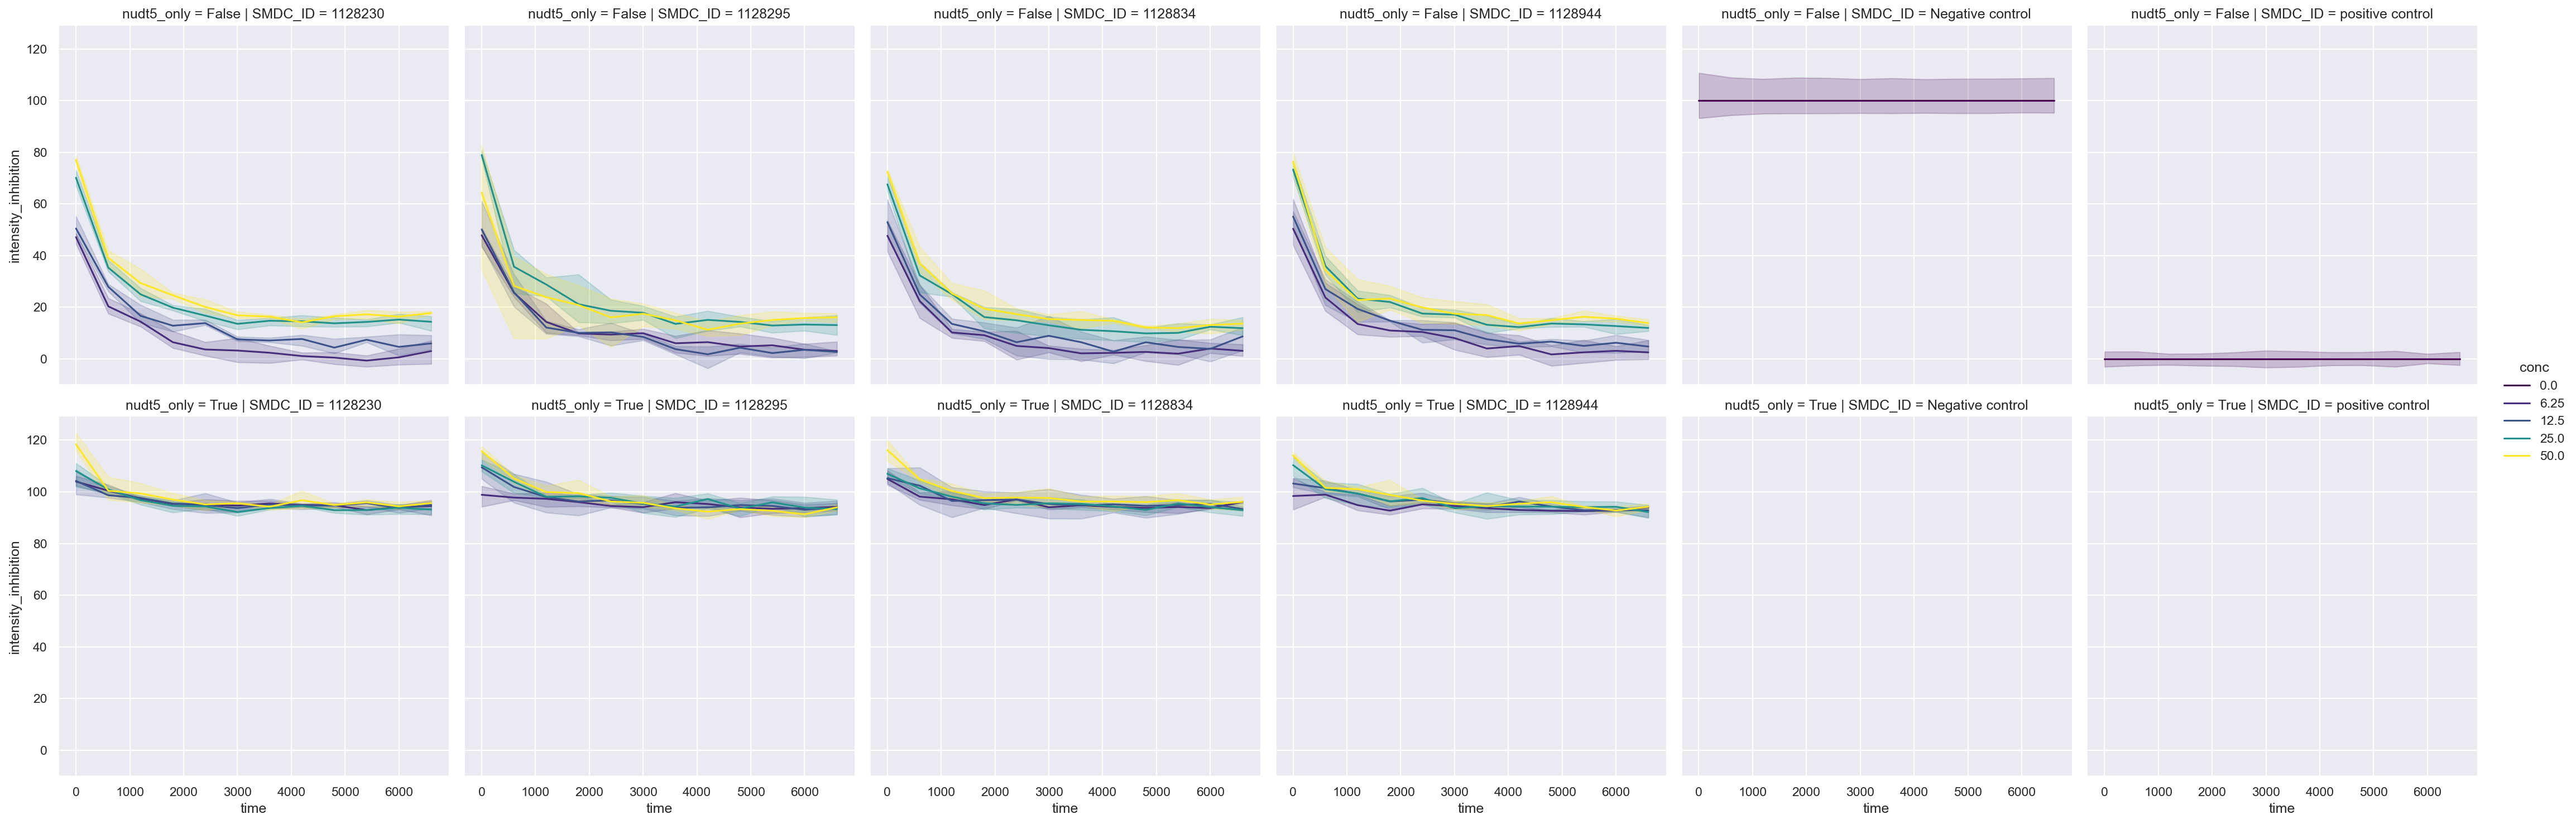

In [21]:
sns.relplot(data=dat_id_conc, x='time', y='intensity_inhibition', hue='conc', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

In [22]:
dat_id_conc.time.unique()

array([5400.119, 3600.086, 3000.071, 2400.053, 1800.038, 1200.023,
        600.01 ,    0.   , 6600.145, 4200.092, 6000.129, 4800.1  ])

In [23]:
dat_id_conc['log_conc_M']=dat_id_conc.conc.apply(lambda x: np.log10(x/1000000) if x>0 else np.nan)

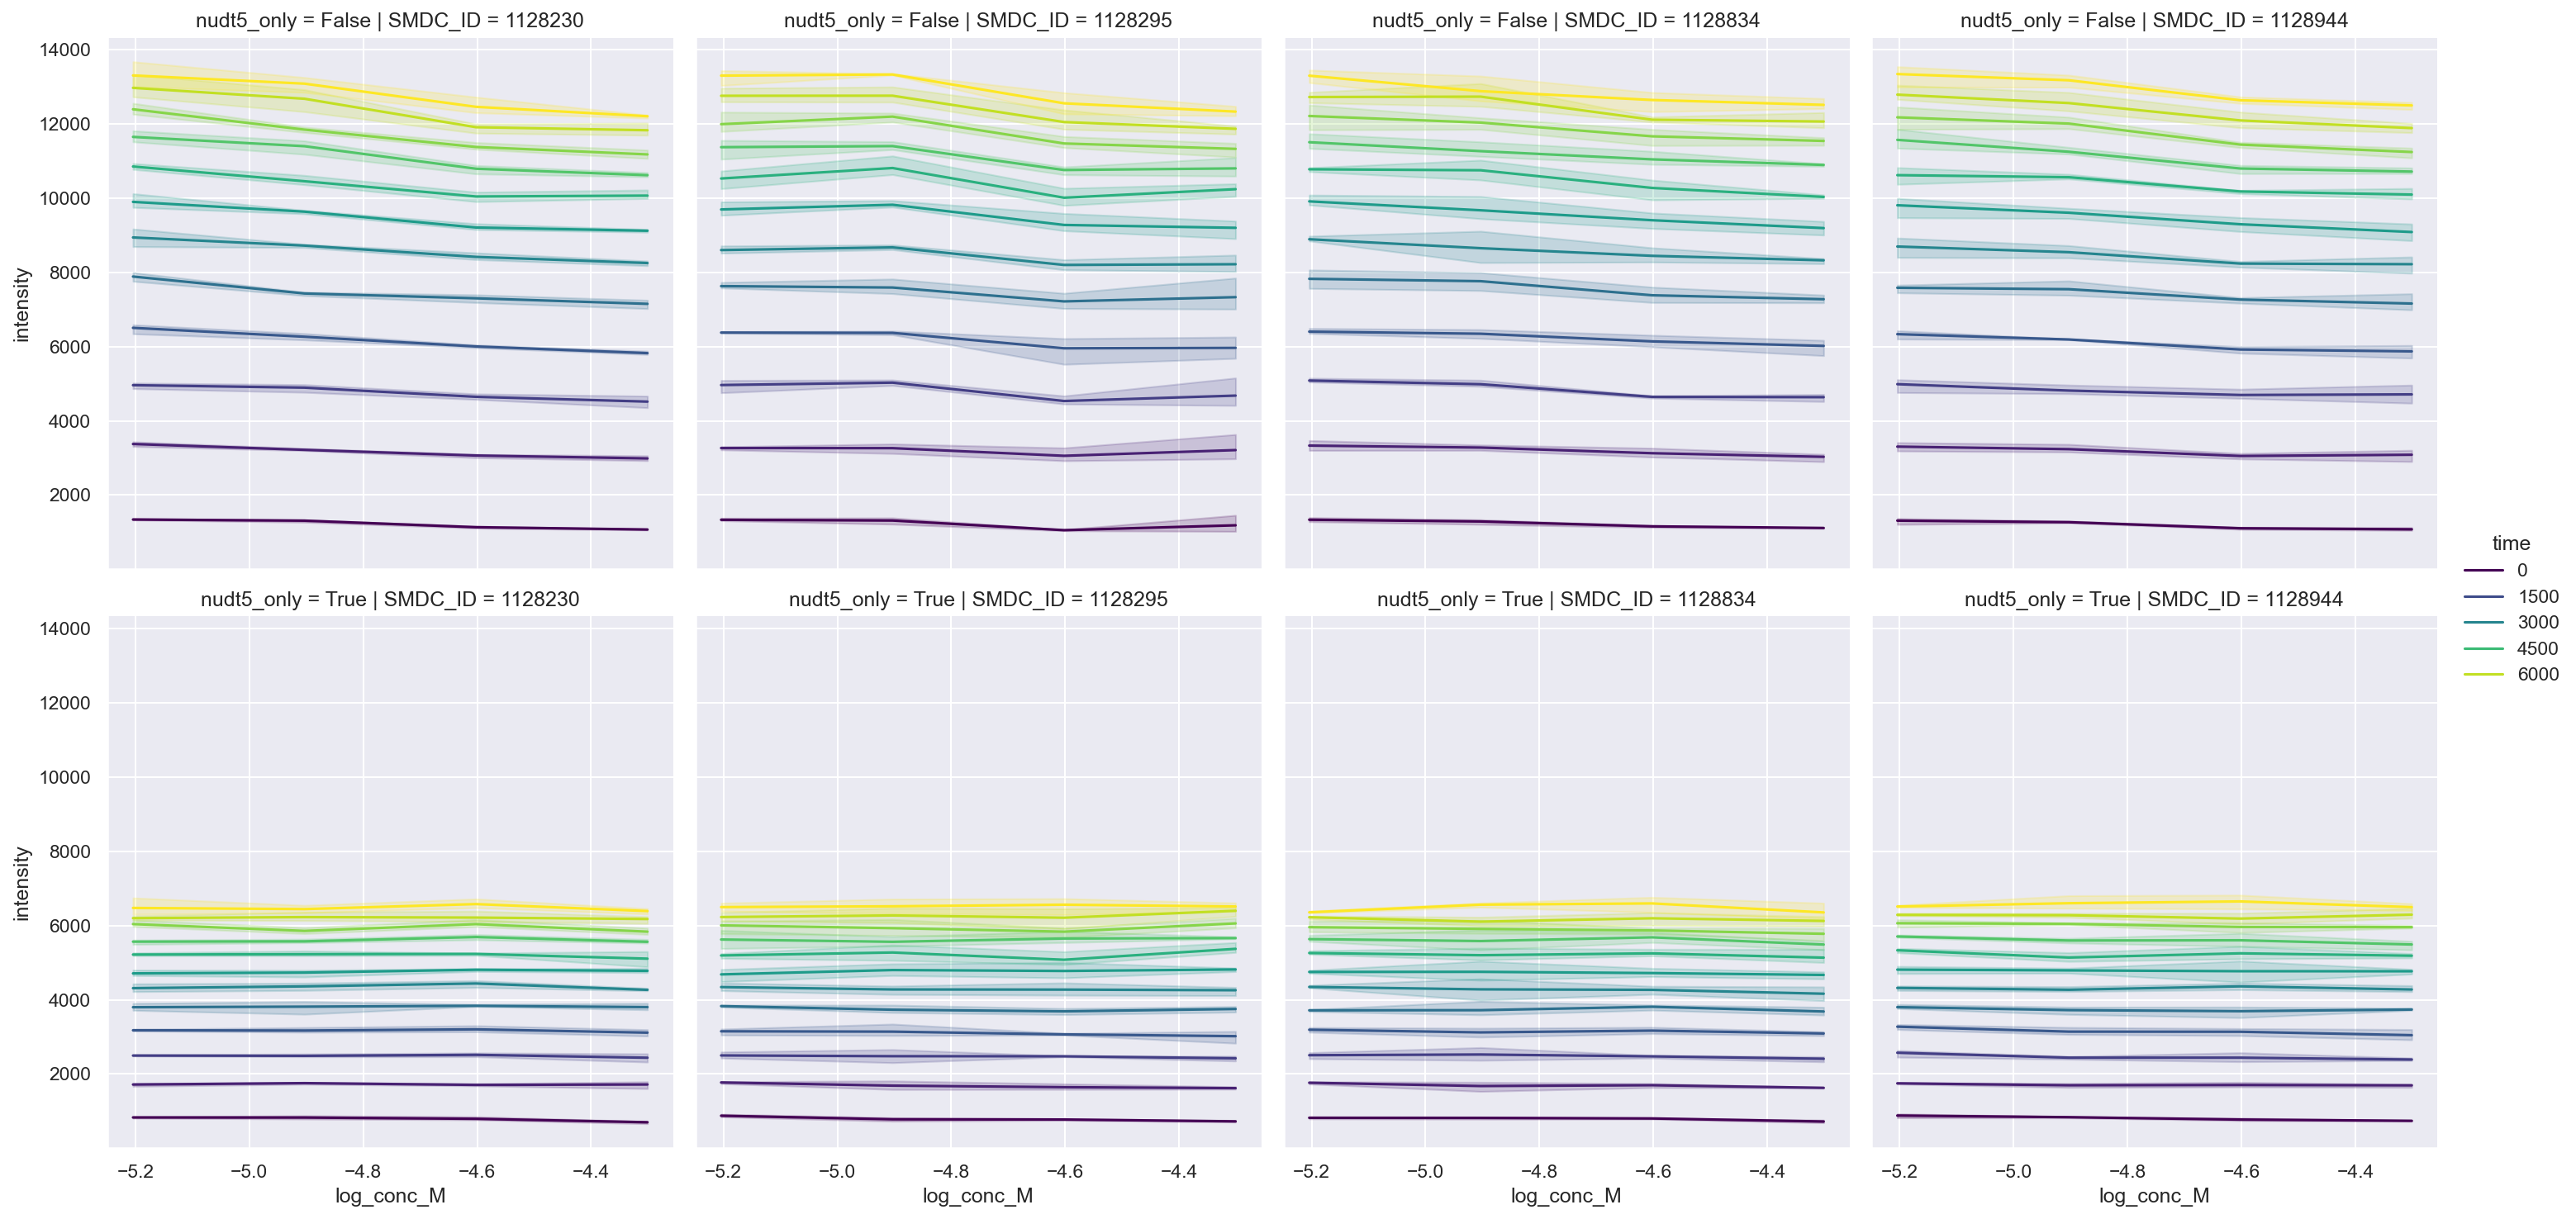

In [24]:
sns.relplot(data=dat_id_conc[dat_id_conc.log_conc_M.notna()], x='log_conc_M', y='intensity', hue='time', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

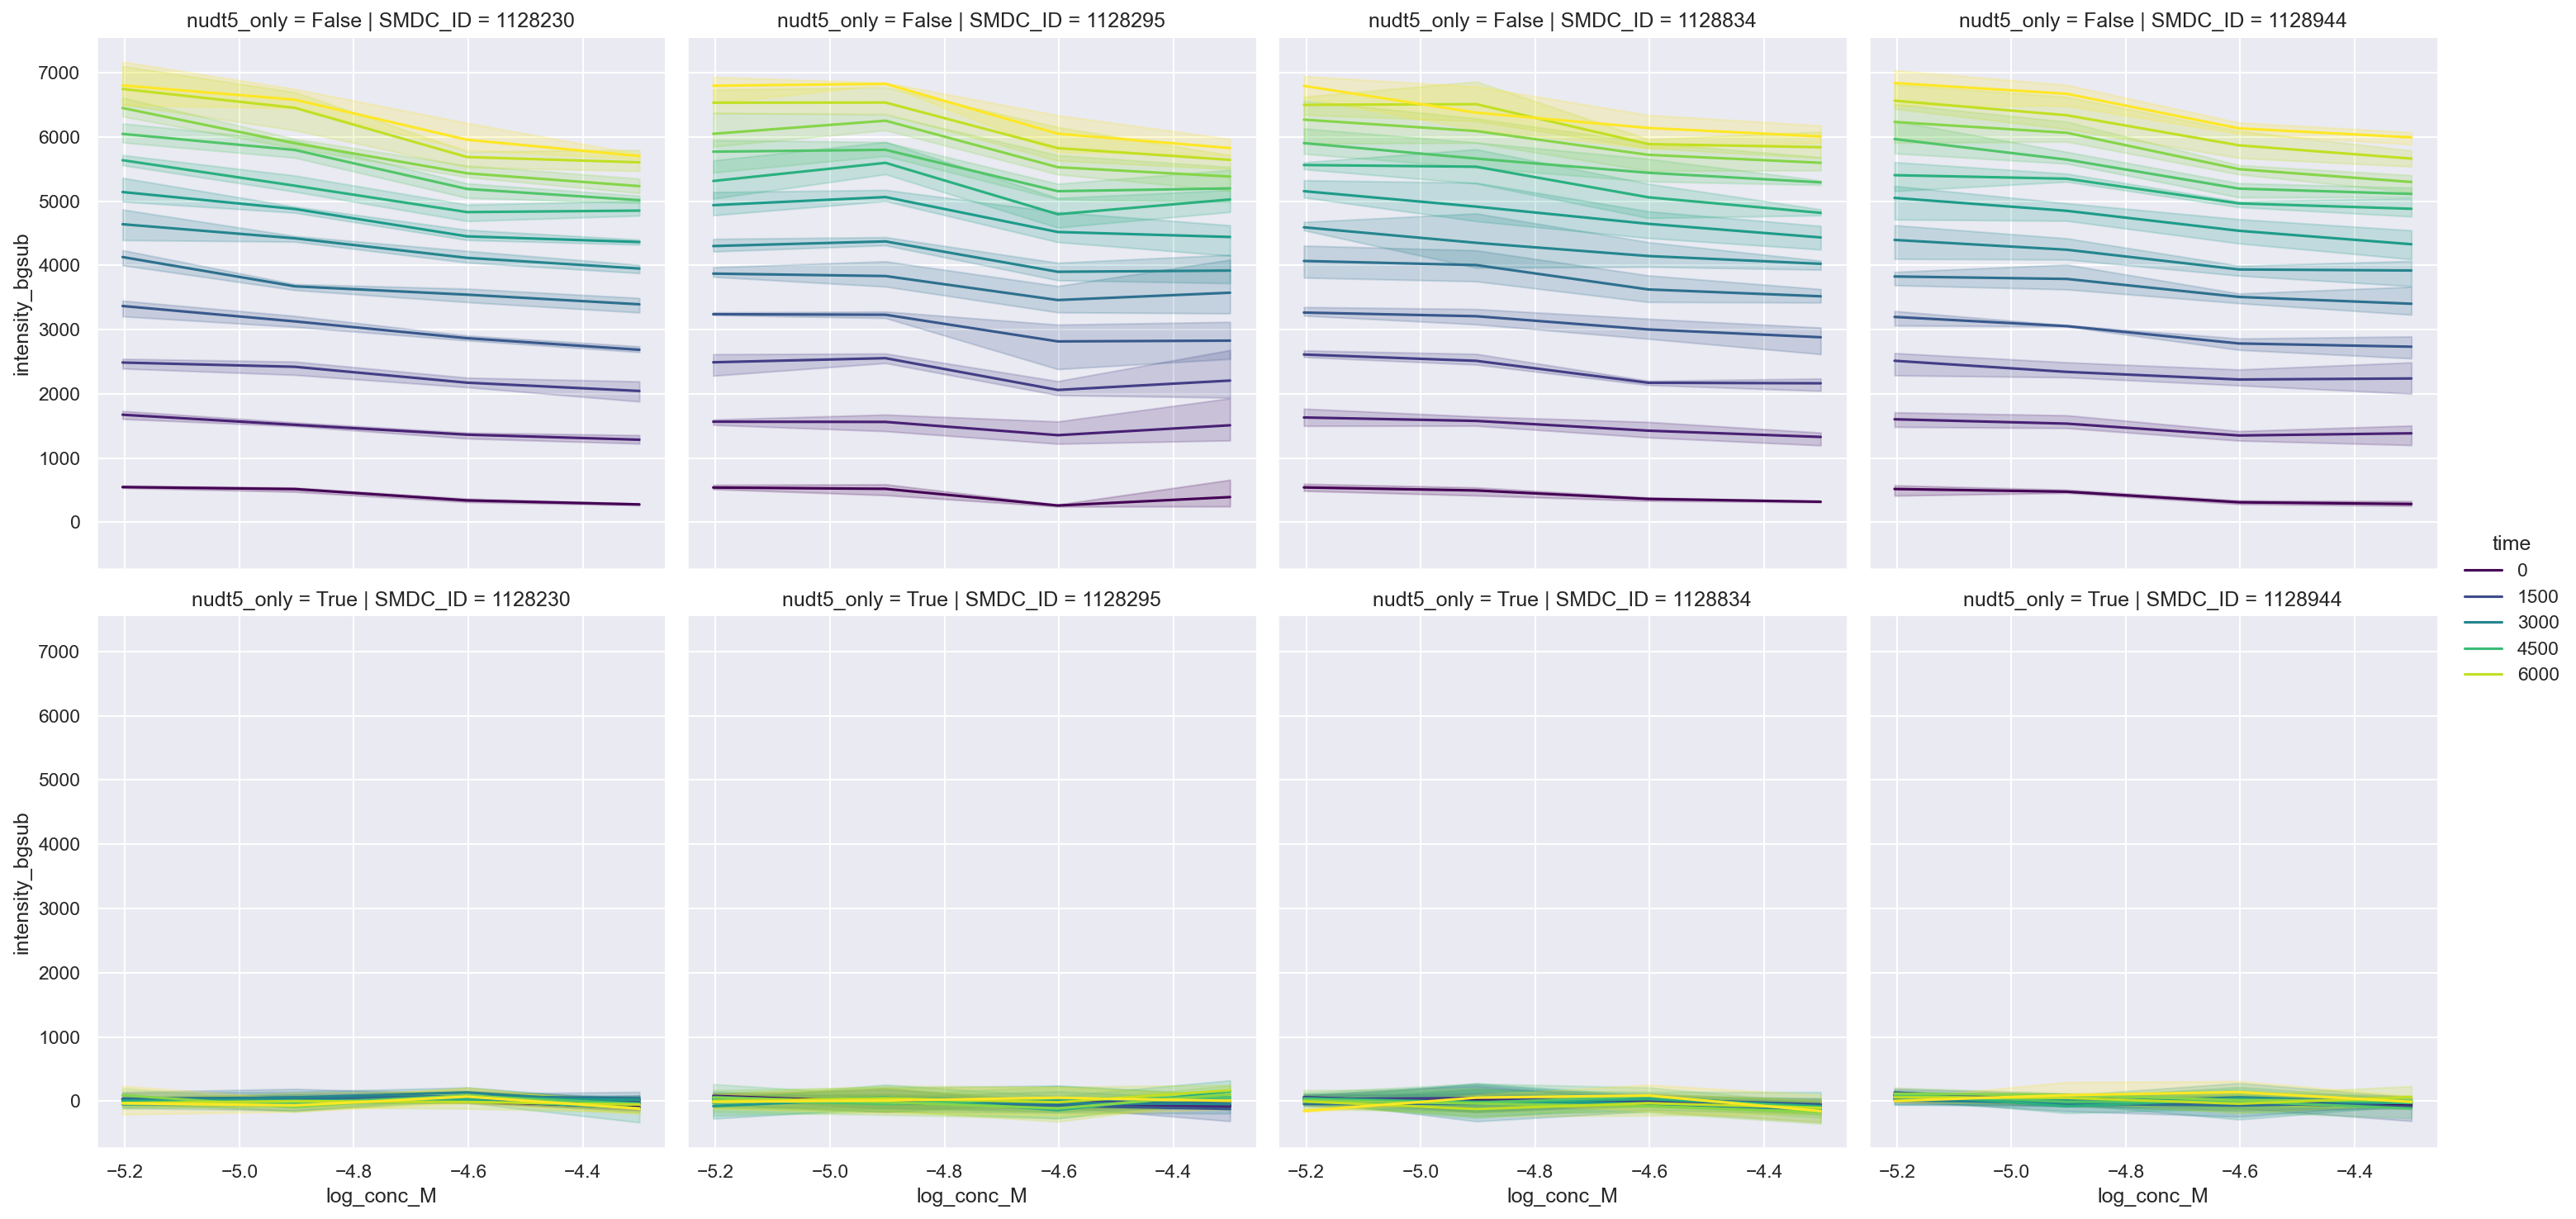

In [25]:
sns.relplot(data=dat_id_conc[dat_id_conc.log_conc_M.notna()], x='log_conc_M', y='intensity_bgsub', hue='time', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

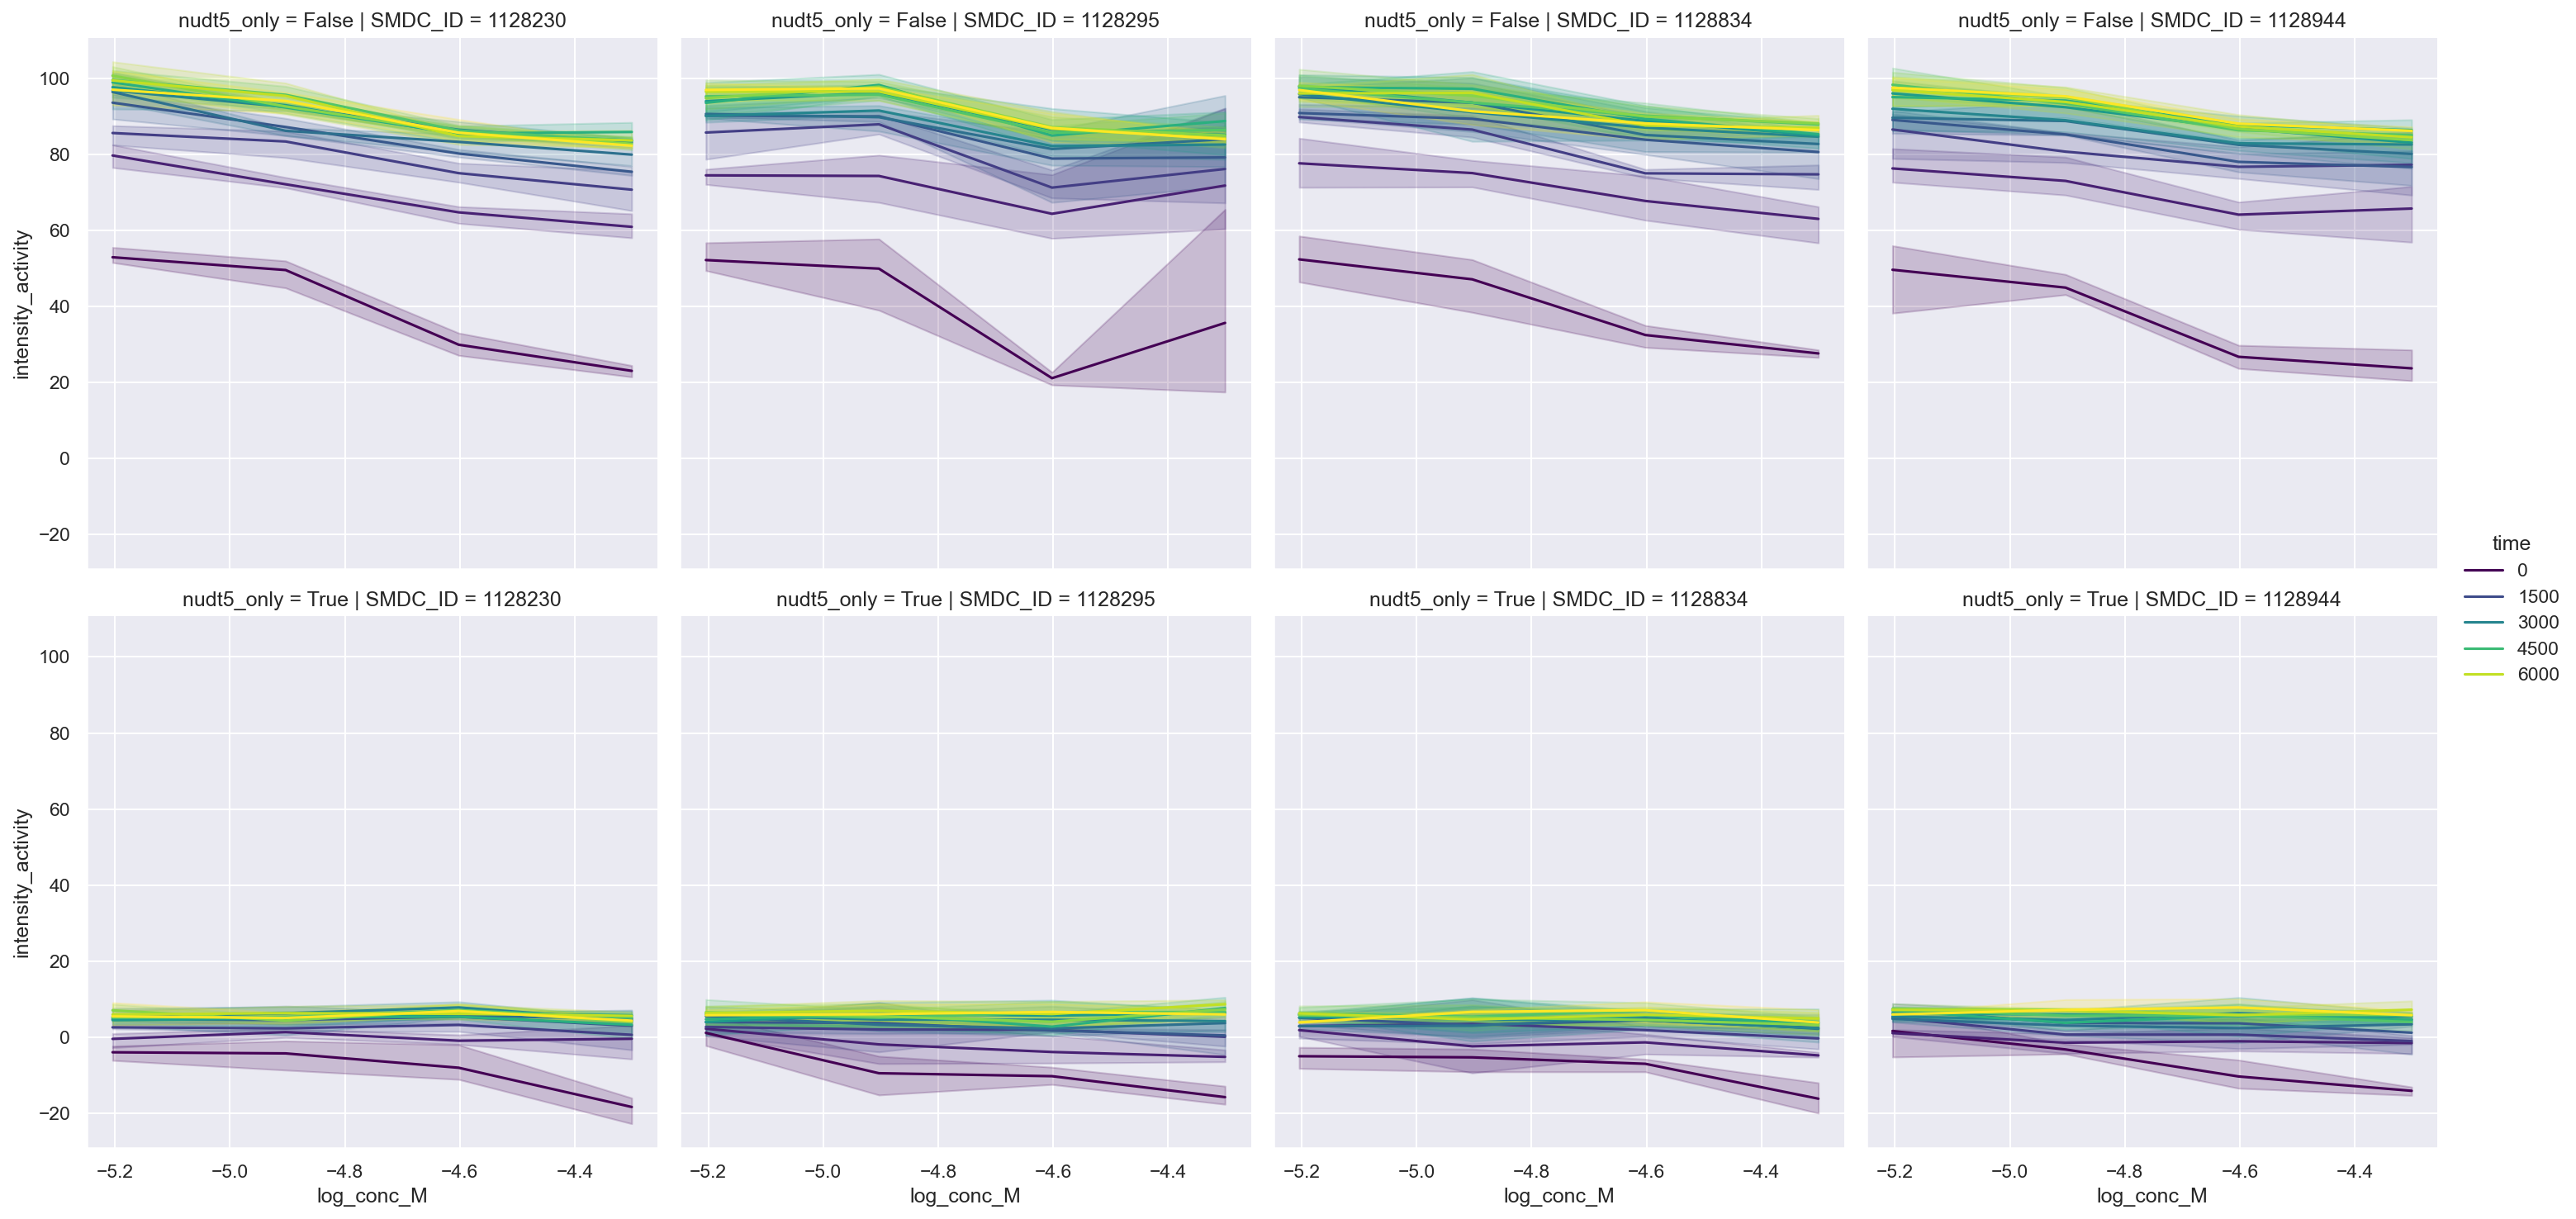

In [26]:
sns.relplot(data=dat_id_conc[dat_id_conc.log_conc_M.notna()], x='log_conc_M', y='intensity_activity', hue='time', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

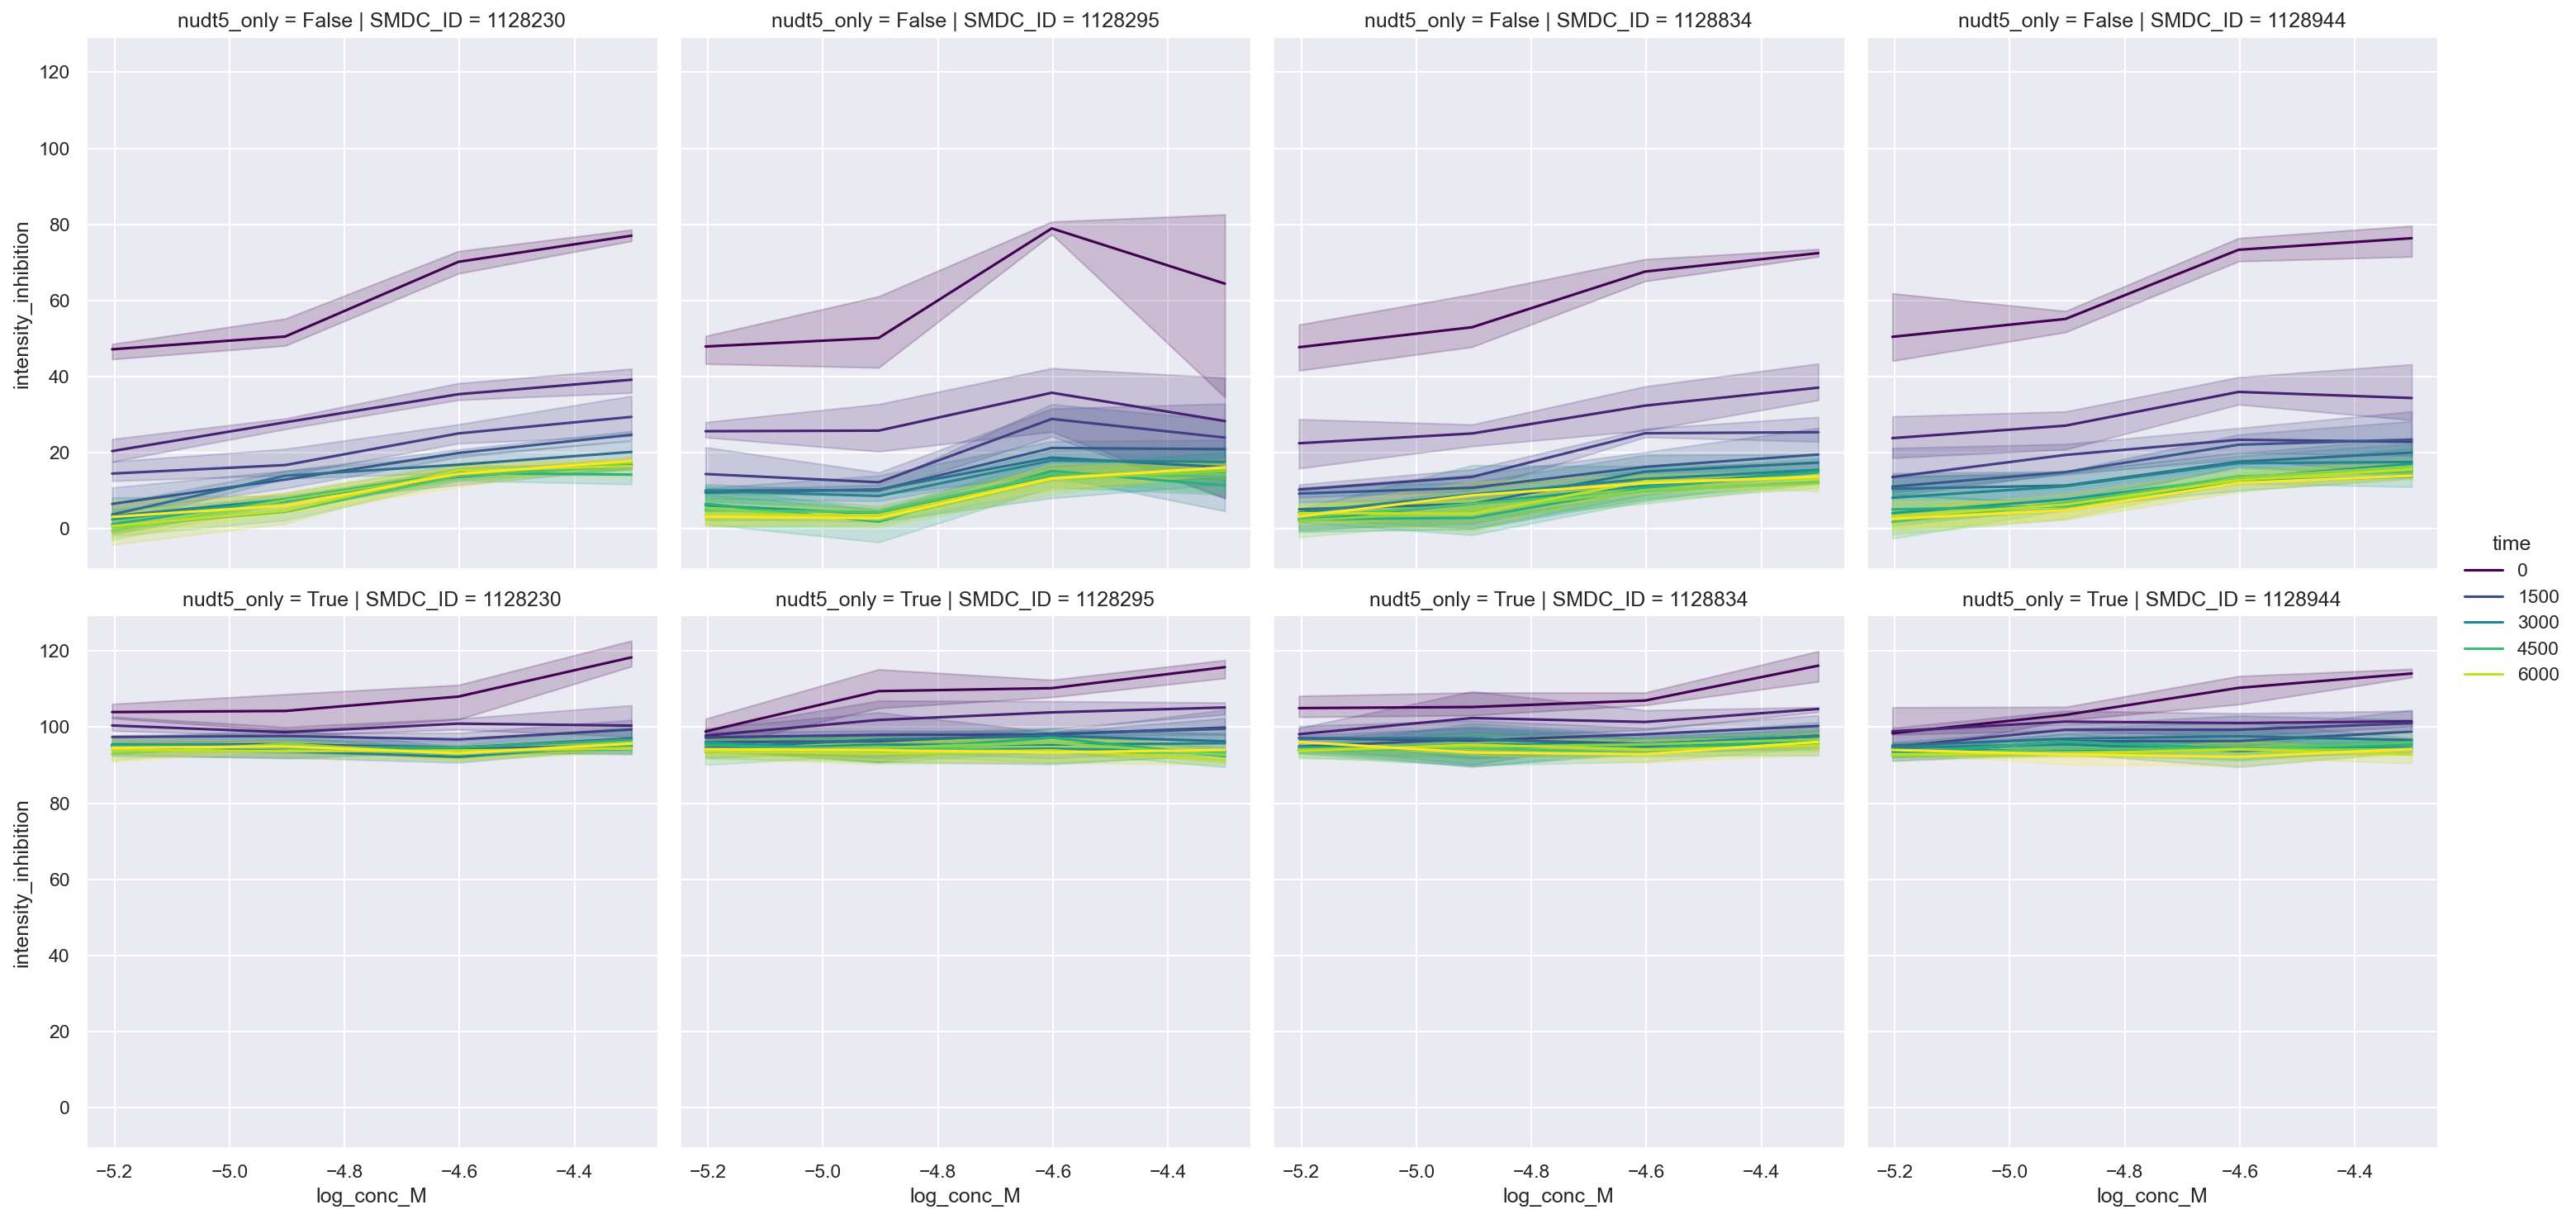

In [27]:
sns.relplot(data=dat_id_conc[dat_id_conc.log_conc_M.notna()], x='log_conc_M', y='intensity_inhibition', hue='time', col='SMDC_ID', row='nudt5_only', palette='viridis', kind='line')

In [28]:
times=dat_id_conc.time.unique().tolist()
times.sort()
times

[0.0,
 600.01,
 1200.023,
 1800.038,
 2400.053,
 3000.071,
 3600.086,
 4200.092,
 4800.1,
 5400.119,
 6000.129,
 6600.145]

In [29]:
dat_id_conc.SMDC_ID=dat_id_conc.SMDC_ID.astype(str)

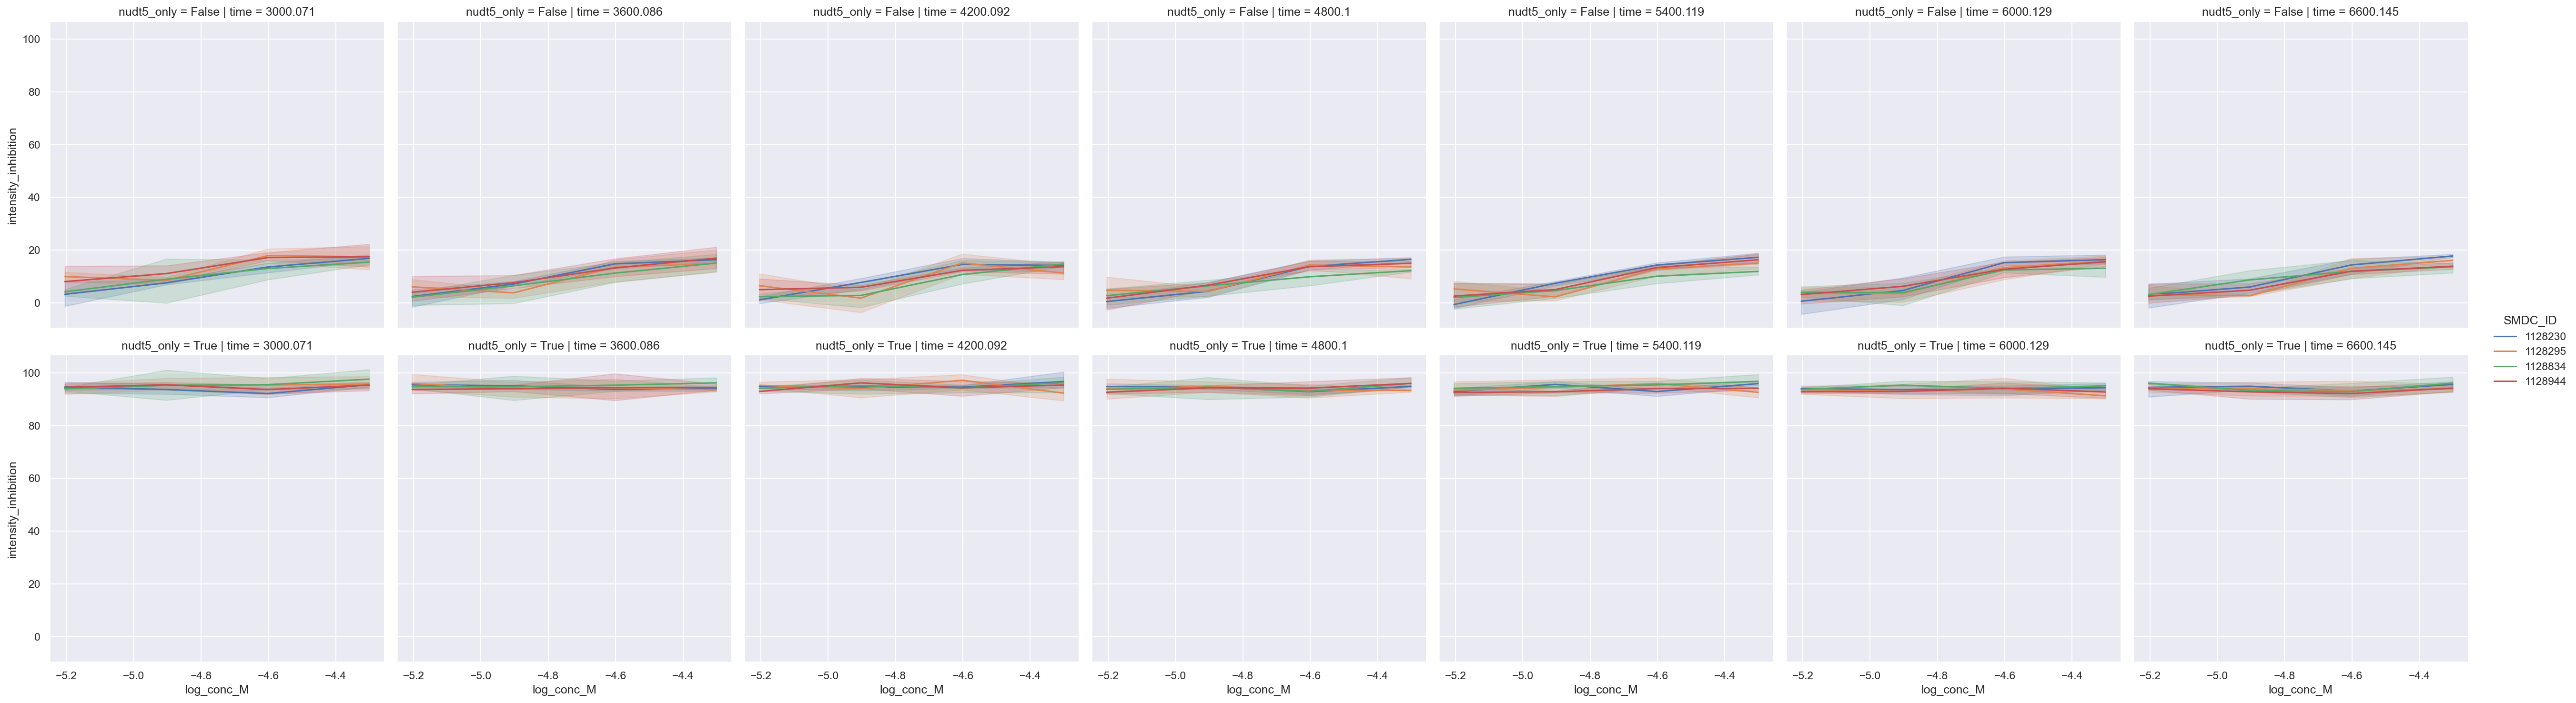

In [30]:
sns.relplot(data=dat_id_conc[(dat_id_conc.log_conc_M.notna())&(dat_id_conc.time>3000)], x='log_conc_M', y='intensity_inhibition', hue='SMDC_ID', col='time', row='nudt5_only', kind='line')

In [31]:
dat_id_conc.to_csv("/Volumes/Shared/SMDC/Screens/2025_users_temp/Deepthi/all_data/AMP_glo_processed.csv", index=False)

In [32]:
dat_id_conc.SMDC_ID=dat_id_conc.SMDC_ID.replace({'positive control':np.nan, 'Negative control':np.nan})
dat_id_conc.SMDC_ID.unique()

array(['1128230', '1128295', '1128834', '1128944', nan], dtype=object)

In [33]:
dat_id_conc[(dat_id_conc.time==3600.086)].to_csv("/Volumes/Shared/SMDC/Screens/2025_users_temp/Deepthi/all_data/AMP_glo_processed_t3600.csv", index=False)

Text(0.5, 1.02, 'Inhibition at 3600s with background subtraction from NUDT5 wells <100uM')

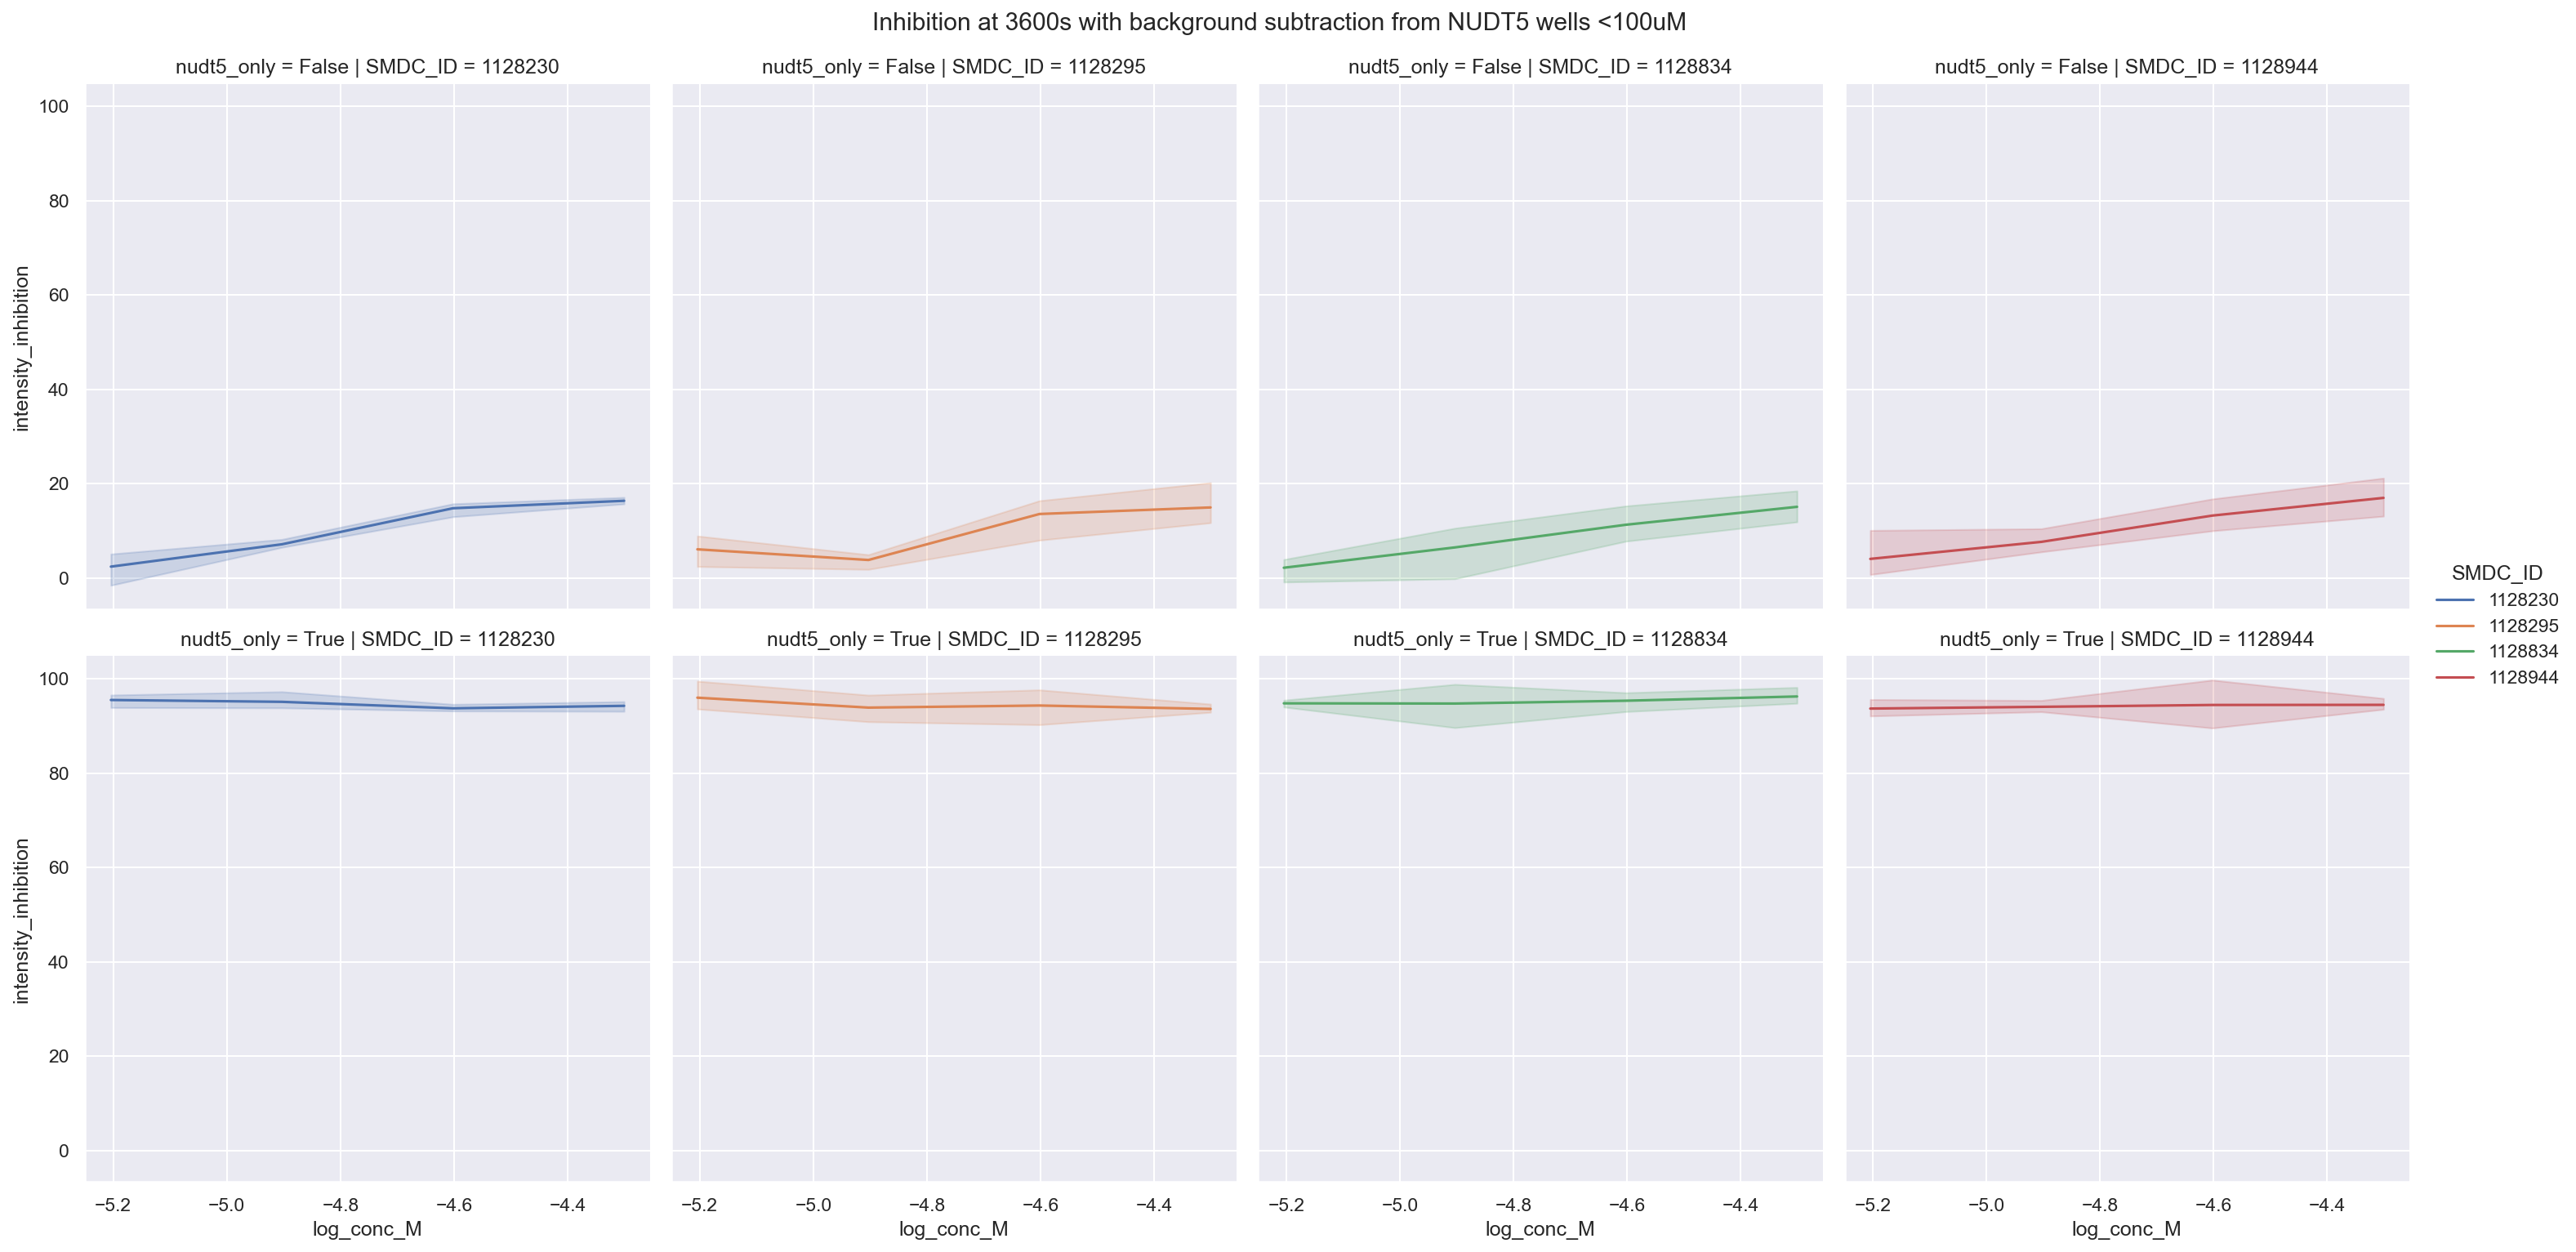

In [34]:
g=sns.relplot(data=dat_id_conc[(dat_id_conc.log_conc_M.notna())&(dat_id_conc.time==3600.086)], x='log_conc_M', y='intensity_inhibition', hue='SMDC_ID', col='SMDC_ID', row='nudt5_only', kind='line')
g.fig.suptitle("Inhibition at 3600s with background subtraction from NUDT5 wells <100uM", y=1.02)

Text(0.5, 1.02, 'Inhibition at 3600s with background subtraction from NUDT5 wells <100uM')

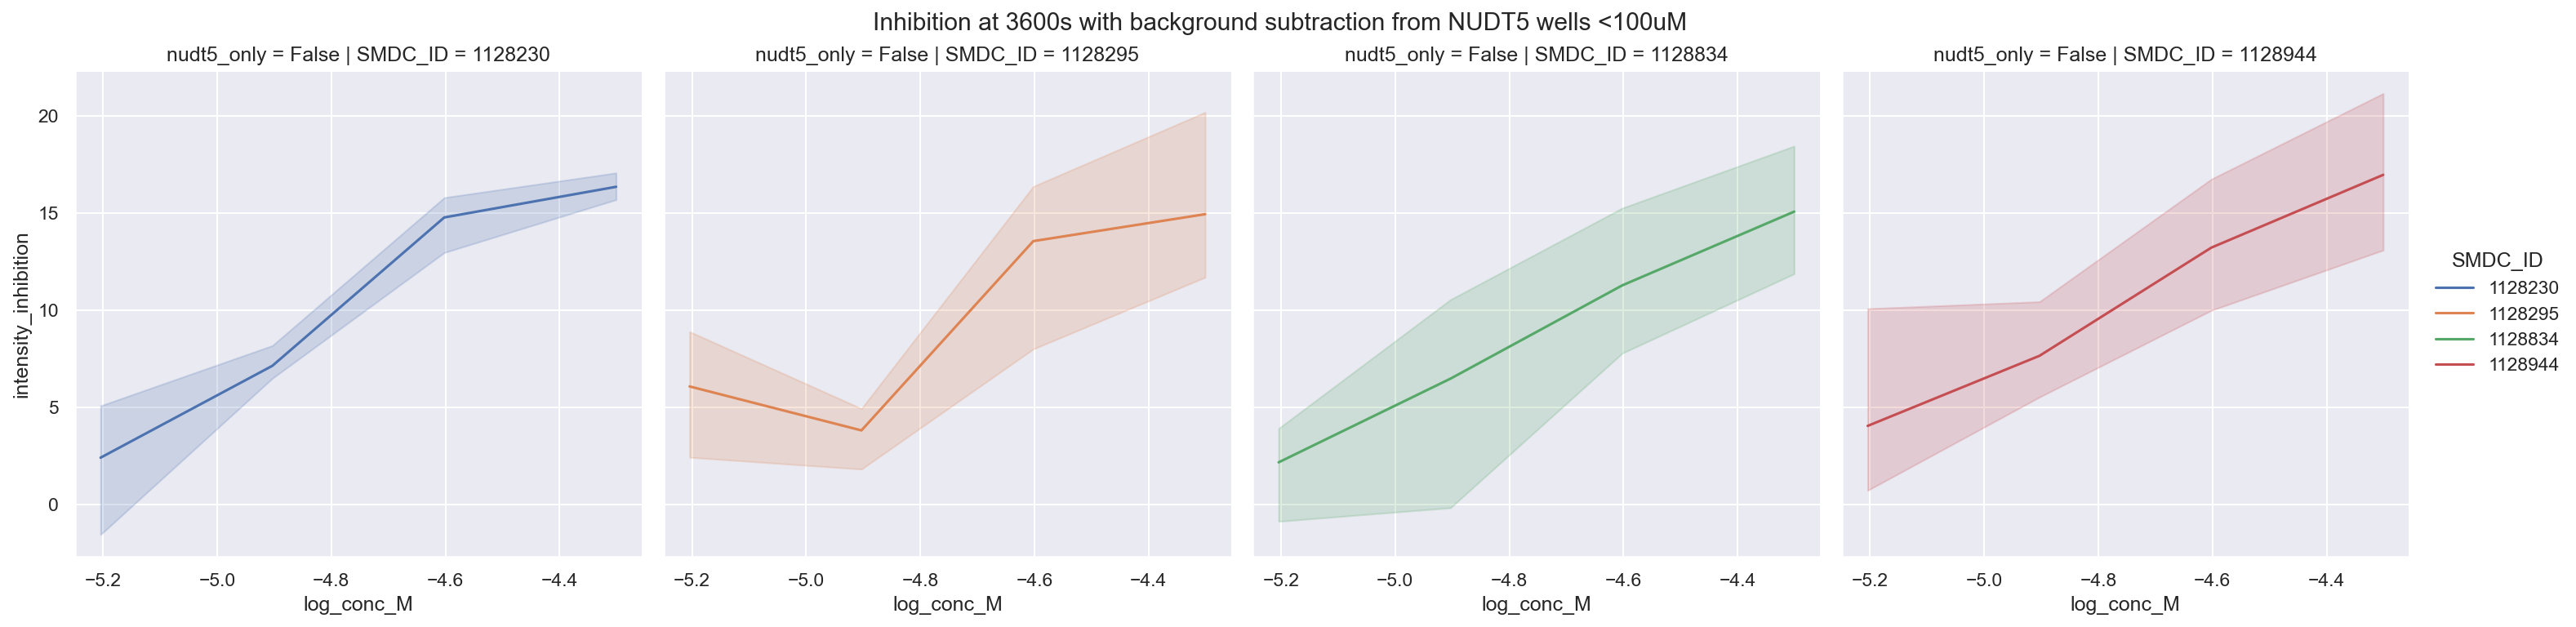

In [35]:
g=sns.relplot(data=dat_id_conc[(dat_id_conc.log_conc_M.notna())&(dat_id_conc.time==3600.086)&(dat_id_conc.nudt5_only==False)], x='log_conc_M', y='intensity_inhibition', hue='SMDC_ID', col='SMDC_ID', row='nudt5_only', kind='line')
g.fig.suptitle("Inhibition at 3600s with background subtraction from NUDT5 wells <100uM", y=1.02)

Text(0.5, 1.02, 'Inhibition at 3600s with background subtraction from NUDT5 wells <100uM')

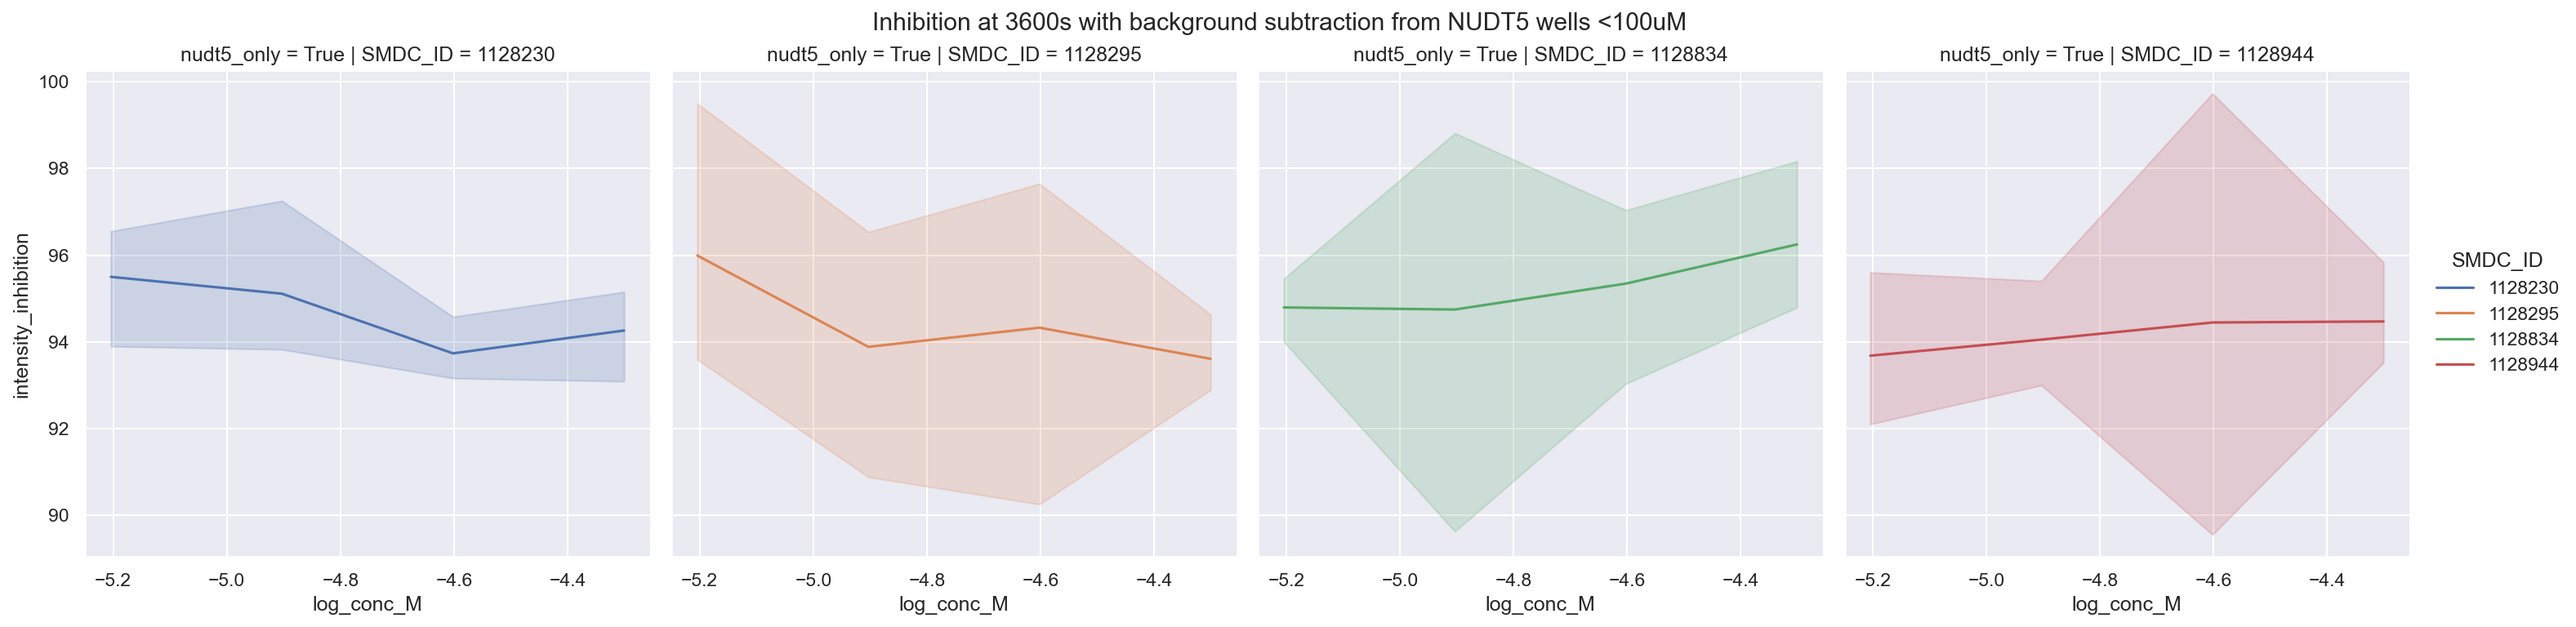

In [36]:
g=sns.relplot(data=dat_id_conc[(dat_id_conc.log_conc_M.notna())&(dat_id_conc.time==3600.086)&(dat_id_conc.nudt5_only==True)], x='log_conc_M', y='intensity_inhibition', hue='SMDC_ID', col='SMDC_ID', row='nudt5_only', kind='line')
g.fig.suptitle("Inhibition at 3600s with background subtraction from NUDT5 wells <100uM", y=1.02)

Text(0.5, 1.02, 'Inhibition at 3600s with background subtraction from NUDT5 wells <100uM')

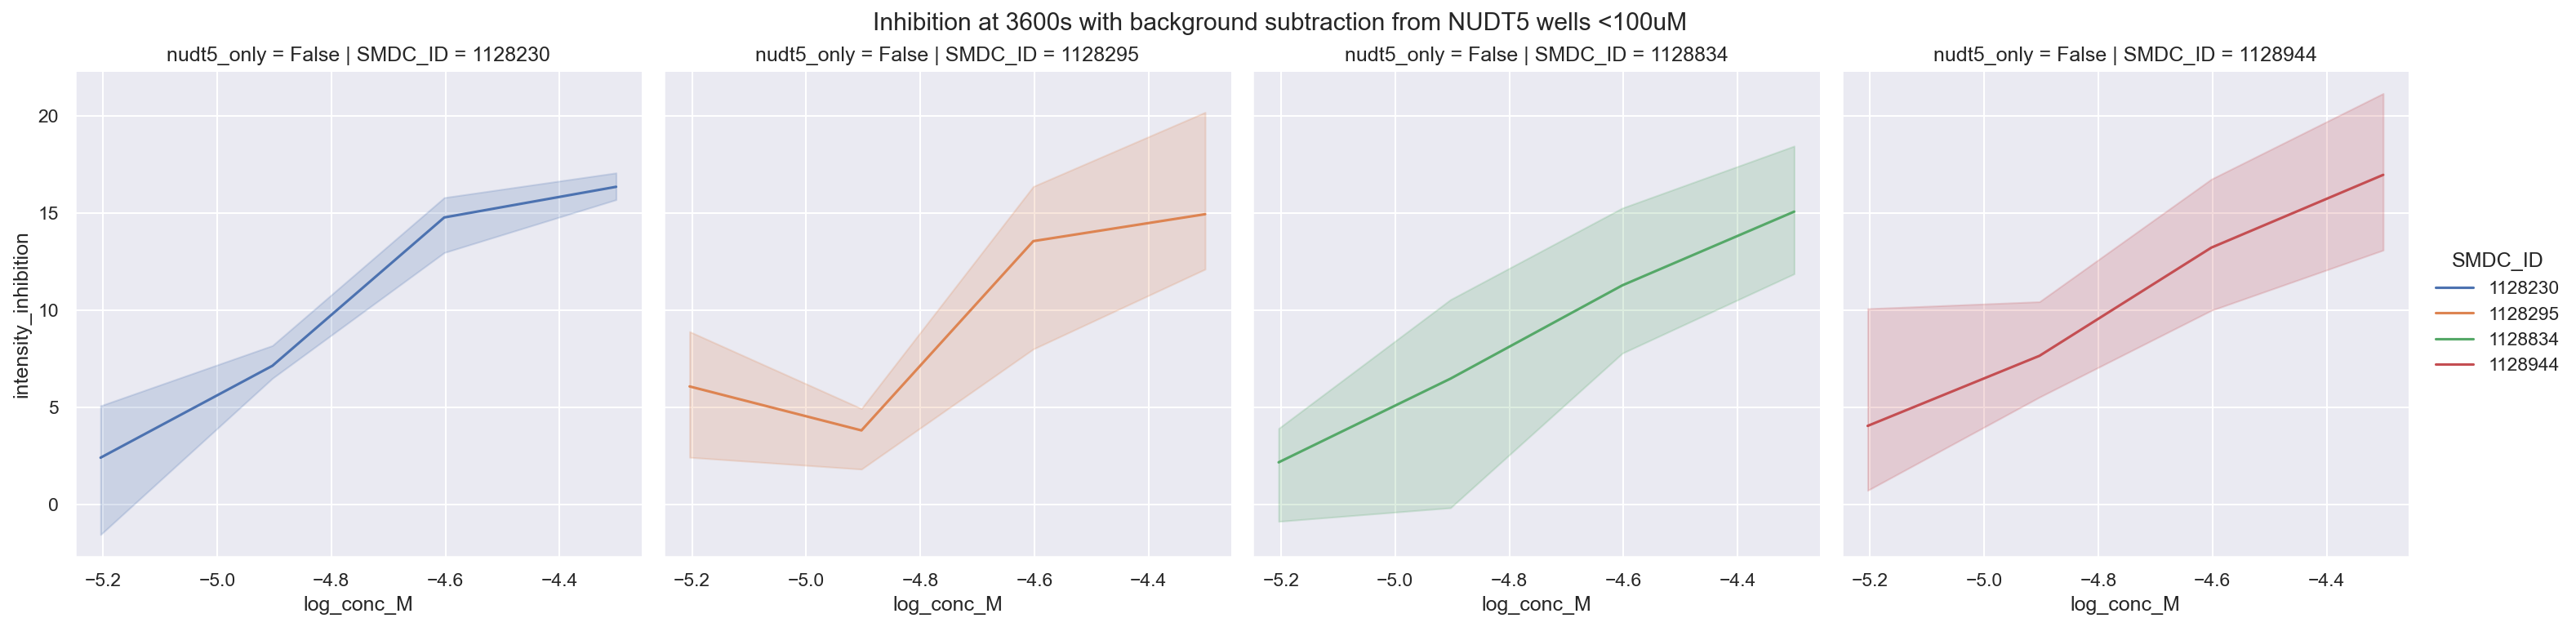

In [37]:
g=sns.relplot(data=dat_id_conc[(dat_id_conc.log_conc_M.notna())&(dat_id_conc.time==3600.086)&(dat_id_conc.nudt5_only==False)&(dat_id_conc.conc!=100)], x='log_conc_M', y='intensity_inhibition', hue='SMDC_ID', col='SMDC_ID', row='nudt5_only', kind='line')
g.fig.suptitle("Inhibition at 3600s with background subtraction from NUDT5 wells <100uM", y=1.02)